# Contexto e Objetivo

### Regime de Fogo em Unidades de Conservação — Classificação em Pirorregiões

Esse projeto nasceu de uma pergunta simples: dá pra entender melhor como o fogo se comporta dentro das Unidades de Conservação federais, olhando não pra vegetação ou pro clima, mas pro próprio padrão do fogo?

A ideia vem de um conceito chamado pirorregião (pyroma), que trata o fogo como algo que tem características próprias, medíveis, que podem ser usadas pra agrupar territórios por semelhança. Duas áreas podem ter vegetação parecida e regime de fogo bem diferente, ou o contrário. Em vez de assumir que fogo e bioma andam sempre juntos, a proposta é medir o comportamento do fogo diretamente e deixar os padrões emergirem dos dados.

A metodologia usada aqui é inspirada no trabalho de Archibald et al, que definiu esse conceito olhando pra cinco características centrais de qualquer regime de fogo:

- frequência, de quanto em quanto tempo uma área volta a queimar
- intensidade, quanta energia o fogo libera quando ocorre
- sazonalidade, em que época do ano o fogo se concentra
- tamanho, a extensão do maior evento já registrado
- extensão média, quanto território queima, em média, todo ano

Essas cinco variáveis são calculadas pixel a pixel, ou no nosso caso célula a célula, numa grade espacial cobrindo o território que queremos estudar. Depois, um algoritmo de clusterização agrupa as células que têm combinações parecidas dessas cinco variáveis, formando grupos. Esses grupos são as pirorregiões, e cada uma representa um tipo distinto de comportamento do fogo, não um tipo de vegetação ou clima:

- FIL (Frequent Intense Large): fogo frequente, intenso e de grande extensão
- FCS (Frequent Cool Small): fogo frequente, de baixa intensidade e pequena extensão
- RIL (Rare Intense Large): fogo raro, intenso e de grande extensão. 
- RCS (Rare Cool Small): fogo raro, de baixa intensidade e pequena extensão.
- ICS (Intermediate Cool Small): fogo de frequência intermediária, baixa intensidade e pequena extensão.

O objetivo final do projeto é gerar essa classificação para o território das Unidades de Conservação federais brasileiras, entender o que cada pirorregião resultante representa em termos práticos, e usar isso como ponto de partida pra pensar estratégias de manejo do fogo mais adequadas a cada contexto, em vez de aplicar a mesma lógica em todo lugar.

---

Esse é um projeto em construção, com decisões metodológicas sendo tomadas e registradas conforme o trabalho avança pelas etapas de preparação dos dados, análise exploratória, pré-processamento e classificação.

In [2]:
# Bibliotecas padrão
import os
import re
import gc
import json
import shutil
import zipfile

# Bibliotecas de terceiros
import ee
import geemap
import requests
import urllib3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from io import BytesIO
from glob import glob

print("Bibliotecas carregadas")

Bibliotecas carregadas


In [3]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [4]:
# mostrar todas as colunas
pd.set_option("display.max_columns", None)

# não quebrar a largura da tabela
pd.set_option("display.expand_frame_repr", False)

# opcional: aumentar a largura máxima exibida
pd.set_option("display.width", 1000)

In [5]:
os.environ["GDAL_DATA"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "gdal"
)
os.environ["PROJ_LIB"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "proj"
)

In [6]:
FILES_DIR = "files"
os.makedirs(FILES_DIR, exist_ok=True)

In [90]:
def load_prepared_data(files_dir):
    outputs_dir = os.path.join(files_dir, "prepared")

    gdf_grid = gpd.read_parquet(os.path.join(outputs_dir, "grid.parquet"))
    cell_uc_membership = pd.read_parquet(os.path.join(outputs_dir, "cell_uc_membership.parquet"))
    gdf_aaf_metric = gpd.read_parquet(os.path.join(outputs_dir, "aaf_clipped.parquet"))
    aaf_events_unique = gpd.read_parquet(os.path.join(outputs_dir, "aaf_events_unique.parquet"))
    gdf_inpe_with_cell = gpd.read_parquet(os.path.join(outputs_dir, "inpe_with_cell.parquet"))
    gdf_ucs_metric = gpd.read_parquet(os.path.join(outputs_dir, "ucs_metric.parquet"))

    print("Grid:", gdf_grid.shape)
    print("Cell-UC membership:", cell_uc_membership.shape)
    print("AAF (recortado por célula):", gdf_aaf_metric.shape)
    print("AAF (eventos únicos):", aaf_events_unique.shape)
    print("INPE:", gdf_inpe_with_cell.shape)
    print("UCs:", gdf_ucs_metric.shape)

    return gdf_grid, cell_uc_membership, gdf_aaf_metric, aaf_events_unique, gdf_inpe_with_cell, gdf_ucs_metric

# Importação dos dados
O projeto usa três fontes de dado, cada uma cumprindo um papel específico dentro das cinco variáveis do regime de fogo.

**Limites das Unidades de Conservação**

Vem do serviço WFS da INDE, mantido pelo ICMBio. É a base espacial de tudo, define onde fica cada UC e serve pra recortar a grade de células que vai ser usada no resto do projeto, sem esses limites não tem como saber quais eventos de fogo e quais focos de calor pertencem a qual UC.

**AAF, Área Afetada por Fogo (ICMBio)**

Registros de cicatrizes de fogo já confirmadas, mapeadas ano a ano desde 2010 até o ano corrente. Cada registro tem data, área queimada e a UC onde ocorreu. É a fonte usada pra calcular frequência, sazonalidade, tamanho do evento e extensão média anual, porque representa fogo que de fato aconteceu e foi validado, não só uma suspeita de calor detectada por satélite.

O acesso é feito via API do ArcGIS FeatureServer do ICMBio. Um detalhe importante descoberto ao longo do projeto: o nome do serviço muda de ano pra ano (às vezes até o esquema de colunas muda), então o download precisa lidar com essas variações e depois harmonizar tudo numa estrutura só antes de usar.

**Foco de calor (INPE)**

Detecções térmicas por satélite, disponíveis desde 2003. Diferente do AAF, um foco de calor não significa necessariamente uma cicatriz de fogo confirmada, é só uma anomalia térmica captada do espaço. Por isso essa fonte é usada só pra calcular intensidade, que é medida em energia radiativa e só o INPE fornece esse dado.

O download é feito ano a ano, direto do servidor público de dados abertos do INPE.

### Unidades de Conservação Federais - INDE/ICMBio

In [7]:
# Limites das UCs federais, via serviço WFS da INDE/ICMBio

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, "wb") as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

print("Shape:", gdf_ucs.shape)
print("Columns:", gdf_ucs.columns.tolist())
print("CRS:", gdf_ucs.crs)

Already downloaded: files\limites_ucs\limites_ucs.geojson
Shape: (347, 22)
Columns: ['ogc_fid', 'id', 'nomeuc', 'cnuc', 'criacaoano', 'areahaalb', 'perimm', 'criacaoato', 'esferaadm', 'grupouc', 'biomas', 'gregional', 'fusoabrang', 'demarcacao', 'escalauc', 'bioma_pred', 'cat_iucn', 'uf', 'categoria_', 'sigla_cate', 'dominio', 'geometry']
CRS: EPSG:4674


In [8]:
# Reprojetar para CRS métrico, necessário pra qualquer cálculo de área ou distância real

METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic

gdf_ucs_metric = gdf_ucs.to_crs("EPSG:5880")
gdf_ucs_metric["geometry"] = gdf_ucs_metric.geometry.buffer(0)  # corrige geometrias inválidas

print("Geometrias inválidas em gdf_ucs_metric:", (~gdf_ucs_metric.is_valid).sum())

Geometrias inválidas em gdf_ucs_metric: 0


### Foco de Calor  INPE

In [9]:
# Download do foco de calor, ano a ano


inpe_dir = os.path.join(FILES_DIR, "inpe_focos")
os.makedirs(inpe_dir, exist_ok=True)

INPE_YEARS = [2003, 2025]
inpe_years_to_download = (
    INPE_YEARS
    if len(INPE_YEARS) == 1
    else list(range(min(INPE_YEARS), max(INPE_YEARS) + 1))
)


inpe_downloaded_files = {}

for year in inpe_years_to_download:

    csv_filename = f"focos_br_ref_{year}.csv"
    csv_path = os.path.join(inpe_dir, csv_filename)

    if os.path.exists(csv_path):
        inpe_downloaded_files[year] = csv_path
        continue

    zip_url = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_todos_sats/focos_br_todos-sats_{year}.zip"

    try:
        response = requests.get(zip_url, timeout=180)
        response.raise_for_status()

        tmp_dir = os.path.join(inpe_dir, f"tmp_{year}")
        os.makedirs(tmp_dir, exist_ok=True)

        with zipfile.ZipFile(BytesIO(response.content)) as z:
            z.extractall(tmp_dir)

        found_csvs = glob(os.path.join(tmp_dir, "**", "*.csv"), recursive=True)

        if found_csvs:
            shutil.move(found_csvs[0], csv_path)
            inpe_downloaded_files[year] = csv_path
        else:
            print(f"[{year}] No CSV found in zip")

        shutil.rmtree(tmp_dir, ignore_errors=True)

    except requests.exceptions.RequestException:
        print(f"[{year}] Download failed")

print("Done:", list(inpe_downloaded_files.keys()))

Done: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [10]:
# Leitura e filtro espacial do foco de calor, ano a ano
# Processar um ano por vez evita estourar memória com o volume total (dezenas de milhões de linhas)

colunas_necessarias = [
    "latitude", "longitude", "data_pas", "satelite", "bioma",
    "estado", "municipio", "frp", "risco_fogo", "numero_dias_sem_chuva",
]

dtypes_reduzidos = {
    "satelite": "category", "bioma": "category", "estado": "category",
    "municipio": "category", "frp": "float32", "risco_fogo": "float32",
    "numero_dias_sem_chuva": "float32", "latitude": "float64", "longitude": "float64",
}

inpe_df_list = []

for year, path in inpe_downloaded_files.items():

    df_year = pd.read_csv(path, usecols=colunas_necessarias, dtype=dtypes_reduzidos)

    # geometria temporária, só pra filtrar espacialmente este ano, descartada em seguida
    points_year = gpd.GeoDataFrame(
        df_year[["latitude", "longitude"]],
        geometry=gpd.points_from_xy(df_year["longitude"], df_year["latitude"]),
        crs="EPSG:4326",
    ).to_crs(METRIC_CRS)

    matched = gpd.sjoin(
        points_year, gdf_ucs_metric[["cnuc", "geometry"]],
        how="inner", predicate="within",
    )

    df_year_filtered = df_year.loc[matched.index].copy()
    df_year_filtered["file_year"] = year

    print(f"[{year}] Total: {len(df_year)} | Dentro de alguma UC: {len(df_year_filtered)}")

    inpe_df_list.append(df_year_filtered)

    del df_year, points_year, matched, df_year_filtered
    gc.collect()

df_inpe = pd.concat(inpe_df_list, ignore_index=True)
del inpe_df_list
gc.collect()

print("\nShape final, já filtrado por UC:", df_inpe.shape)
print("Anos presentes:", sorted(df_inpe["file_year"].unique()))

[2003] Total: 966656 | Dentro de alguma UC: 29283
[2004] Total: 1149637 | Dentro de alguma UC: 34684
[2005] Total: 1075006 | Dentro de alguma UC: 33264
[2006] Total: 678258 | Dentro de alguma UC: 23871
[2007] Total: 1153803 | Dentro de alguma UC: 38341
[2008] Total: 642397 | Dentro de alguma UC: 21645
[2009] Total: 427119 | Dentro de alguma UC: 12774
[2010] Total: 1103840 | Dentro de alguma UC: 47331
[2011] Total: 516137 | Dentro de alguma UC: 21234
[2012] Total: 2562540 | Dentro de alguma UC: 114294
[2013] Total: 1301523 | Dentro de alguma UC: 48037
[2014] Total: 1855400 | Dentro de alguma UC: 82398
[2015] Total: 2638964 | Dentro de alguma UC: 112881
[2016] Total: 1982628 | Dentro de alguma UC: 88590
[2017] Total: 2864700 | Dentro de alguma UC: 125821
[2018] Total: 1826081 | Dentro de alguma UC: 58706
[2019] Total: 4070300 | Dentro de alguma UC: 189988
[2020] Total: 5212990 | Dentro de alguma UC: 252903
[2021] Total: 4435088 | Dentro de alguma UC: 195855
[2022] Total: 4590402 | Dentro

### Áreas Atingidas por Fogo em UCs - ICMBio

In [11]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = (
        f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"
    )

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [12]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        aaf_downloaded_files[year] = output_path
        continue

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get("features", [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))


Anos baixados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [13]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year["file_year"] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf["file_year"].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'cr', 'GlobalID', 'ngi', 'data_img', 'local', 'gr_nome', 'area_uc', 'bioma', 'mes_num', 'data', 'ano', 'area_ent', 'mes_nome', 'pk_aaf', 'categoria', 'FID', 'ct'}
[2025] Diferença de colunas em relação ao primeiro ano: {'cr', 'GlobalID', 'ngi', 'data_img', 'local', 'gr_nome', 'area_uc', 'Shape__Len', 'bioma', 'acao', 'mes_num', 'data', 'Shape__Are', 'classe', 'ano', 'area_ent', 'mes_nome', 'pk_aaf', 'categoria', 'FID', 'tipo', 'ct'}
[2026] Diferença de colunas em relação ao primeiro ano: {'cr', 'GlobalID', 'ngi', 'data_img', 'local', 'gr_nome', 'area_uc', 'Shape__Len', 'GlobalID_2', 'bioma', 'acao', 'mes_num', 'data', 'Shape__Are', 'classe', 'ano', 'area_ent', 'mes_nome', 'pk_aaf', 'categoria', 'FID', 'tipo', 'ct'}
Shape: (41667, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

In [14]:
# Harmonizar colunas divergentes entre as diferentes eras do esquema do AAF

gdf_aaf["event_year"] = gdf_aaf["file_year"]

# 'data' vem como epoch em milissegundos no esquema antigo, 'data_img' como texto no esquema novo
date_from_old_schema = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")
date_from_new_schema = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
gdf_aaf["event_date"] = date_from_old_schema.combine_first(date_from_new_schema)

# recupera a data via dia juliano, quando 'data' e 'data_img' estão ausentes
julian_fallback = pd.to_datetime(
    gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce"
) + pd.to_timedelta(gdf_aaf["juliano"] - 1, unit="D")
gdf_aaf["event_date"] = gdf_aaf["event_date"].combine_first(julian_fallback)
gdf_aaf["event_month"] = gdf_aaf["event_date"].dt.month

# coalesce entre nomenclatura abreviada e completa do atributo de área do polígono
gdf_aaf["shape_area"] = gdf_aaf["Shape__Are"].combine_first(gdf_aaf["Shape__Area"])
gdf_aaf["shape_length"] = gdf_aaf["Shape__Len"].combine_first(gdf_aaf["Shape__Length"])

# descartar eventos sem data válida em nenhuma das três fontes acima
n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[gdf_aaf["event_date"].notna()].copy()

print(f"Eventos descartados por falta de data: {n_before - len(gdf_aaf)} ({(n_before - len(gdf_aaf)) / n_before * 100:.1f}%)")
print(f"Total de eventos final: {len(gdf_aaf)}")

Eventos descartados por falta de data: 386 (0.9%)
Total de eventos final: 41281


# Preparação dos dados

Aqui os dados brutos das três fontes viram a estrutura usada no resto do projeto: uma grade espacial dentro dos limites das UCs, com AAF e focos de calor vinculados a cada célula.

**Problemas encontrados:**

* **Geometrias inválidas no AAF**: dois registros vieram com geometria malformada, provável auto-interseção no polígono. Corrigidos com `buffer(0)`, e o que ainda ficou inválido depois disso foi descartado.
* **Duplicatas geométricas no AAF**: 238 registros eram cópias exatas de outro evento já existente, mesma geometria byte a byte. Removidas antes de qualquer cálculo.
* **Fragmentação de evento pelo recorte de célula**: um evento que atravessa mais de uma célula da grade vira várias linhas depois do recorte, o que é necessário pra saber quanto de área caiu em cada célula, mas também significa que contar linhas direto conta fragmento, não evento real. `aaf_events_unique` foi criado à parte pra reconstituir o evento original e permitir contagem correta.
* **Valor sentinela no INPE**: as colunas de risco de fogo e dias sem chuva usavam -999 como código de ausência de dado, o que distorcia qualquer média calculada em cima delas. Convertido pra ausência real (NaN) antes de qualquer análise.
* **String "None" no AAF**: a coluna `classe` tinha a palavra "None" escrita como texto em algumas linhas, sendo contada como se fosse uma categoria válida. Corrigida pra ser tratada como ausência real.
* **Esquema de colunas mudando entre anos**: o AAF trocou nome de colunas e formato de data mais de uma vez ao longo da série (`classe` num período, `acao` e `tipo` em outro). Unificadas numa única coluna, `event_type`, seguindo um mapeamento entre as categorias antigas e novas.

**Resultado final:**

Seis datasets persistidos em Parquet:

* `gdf_grid`, malha de 82.045 células
* `cell_uc_membership`, relação célula-UC
* `gdf_aaf_metric`, AAF recortado por célula
* `aaf_events_unique`, eventos sem fragmentação
* `gdf_inpe_with_cell`, focos de calor por célula
* `gdf_ucs_metric`, limites e atributos das UCs

In [125]:
# CELL_SIZE_M = 5000        # tamanho da célula da grade, 5km x 5km
CELL_SIZE_M = 1000        # teste

In [126]:
# Reprojetar AAF

gdf_aaf_metric = gdf_aaf.to_crs(METRIC_CRS)
print("CRS AAF após reprojeção:", gdf_aaf_metric.crs)

CRS AAF após reprojeção: EPSG:5880


In [127]:
gdf_aaf_metric["geometry"] = gdf_aaf_metric.geometry.buffer(0)
print("Geometrias inválidas em gdf_aaf_metric:", (~gdf_aaf_metric.is_valid).sum())

Geometrias inválidas em gdf_aaf_metric: 2


In [128]:
# Descartar volume irrelevante
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[gdf_aaf_metric.is_valid].copy()

print(
    f"\nRegistros descartados por geometria inválida: {n_before - len(gdf_aaf_metric)}"
)
print(f"Total de eventos final: {len(gdf_aaf_metric)}")


Registros descartados por geometria inválida: 2
Total de eventos final: 41279


In [129]:
# Remover as poucas duplicatas geométricas reais
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[
    ~gdf_aaf_metric.geometry.apply(lambda g: g.wkb).duplicated()
].copy()

print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf_metric)}")
print(f"Total final: {len(gdf_aaf_metric)}")

Duplicatas geométricas removidas: 238
Total final: 41041


In [130]:
# Origem global fixa

global_minx, global_miny, _, _ = gdf_ucs_metric.total_bounds

grid_records = []

for idx, row in gdf_ucs_metric.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({"cell_id": f"{i}_{j}", "geometry": clipped})

gdf_grid_raw = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
print("Peças de célula geradas:", len(gdf_grid_raw))

gdf_grid = gdf_grid_raw.dissolve(by="cell_id", as_index=False)
del gdf_grid_raw, grid_records
gc.collect()

print("Total de células globais únicas:", len(gdf_grid))


Peças de célula geradas: 1891159
Total de células globais únicas: 1871136


In [131]:
# Tabela de associação de célula UC.

cell_uc_membership = gpd.sjoin(
    gdf_grid, gdf_ucs_metric[["cnuc", "geometry"]], how="left", predicate="intersects"
)[["cell_id", "cnuc"]]

cells_per_uc_count = cell_uc_membership.groupby("cell_id").size()
print("Células pertencentes a mais de um UC:", (cells_per_uc_count > 1).sum())

Células pertencentes a mais de um UC: 19809


In [132]:
# Atribua eventos AAF a células da grade via sobreposição

gdf_aaf_metric = gpd.overlay(
    gdf_aaf_metric, gdf_grid[["cell_id", "geometry"]], how="intersection"
)

gdf_aaf_metric["area_ha_cell"] = gdf_aaf_metric.geometry.area / 10000

print("Total de linhas após a sobreposição:", len(gdf_aaf_metric))

Total de linhas após a sobreposição: 429470


In [133]:
n_before = len(df_inpe)
df_inpe = df_inpe.drop_duplicates(
    subset=["latitude", "longitude", "data_pas", "satelite", "frp"]
).copy()
print(f"Duplicatas removidas de df_inpe: {n_before - len(df_inpe)}")
print(f"Total final: {len(df_inpe)}")

Duplicatas removidas de df_inpe: 0
Total final: 2565532


In [134]:
# Filtro em cascata para o INPE

gdf_inpe_points = gpd.GeoDataFrame(
    df_inpe,
    geometry=gpd.points_from_xy(df_inpe["longitude"], df_inpe["latitude"]),
    crs="EPSG:4326",
).to_crs(METRIC_CRS)

gdf_inpe_with_cell = gpd.sjoin(
    gdf_inpe_points, gdf_grid[["cell_id", "geometry"]], how="inner", predicate="within"
)

print("Total de pontos:", len(gdf_inpe_points))
print("Total dentro de alguma célula:", len(gdf_inpe_with_cell))

del gdf_inpe_points
gc.collect()

Total de pontos: 2565532
Total dentro de alguma célula: 2565532


0

In [135]:
# Corrigir valor sentinela -999 (INPE) 

gdf_inpe_with_cell['risco_fogo'] = gdf_inpe_with_cell['risco_fogo'].replace(-999, np.nan)
gdf_inpe_with_cell['numero_dias_sem_chuva'] = gdf_inpe_with_cell['numero_dias_sem_chuva'].replace(-999, np.nan)

# Corrigir string "None" tratada como categoria válida em 'classe' (AAF)
gdf_aaf_metric['classe'] = gdf_aaf_metric['classe'].replace('None', np.nan)

In [136]:
# Harmonizar classe (2020-2024) e acao (2025-2026) em uma única coluna de tipo de evento

harmonization_map = {
    'aceiro': 'aceiro',
    'fogo natural': 'natural',
    'raio': 'natural',
    'gestao de ignicao natural': 'natural',
    'incendio': 'incendio',
    'indigena': 'antropica',
    'gestao de ignicao antropica': 'antropica',
    'queima por indigenas isolados': 'antropica',
    'outros': 'outros',
    'queima controlada': 'queima controlada',
    'queima prescrita': 'queima prescrita',
}

gdf_aaf_metric['event_type'] = (
    gdf_aaf_metric['classe']
    .combine_first(gdf_aaf_metric['acao'])
    .map(harmonization_map)
)

In [137]:
# Descartar coluna residual do sjoin, sem uso analítico
gdf_inpe_with_cell = gdf_inpe_with_cell.drop(columns=['index_right'], errors='ignore')

In [138]:
# Salvar eventos únicos do AAF como dataset separado
# evita contar o mesmo evento várias vezes por causa do recorte por célula

event_key_cols = ['cnuc', 'area_ha', 'event_date', 'satelite']
aaf_events_unique = gdf_aaf_metric.drop_duplicates(subset=event_key_cols).copy()

print("Linhas recortadas (por célula):", len(gdf_aaf_metric))
print("Eventos únicos:", len(aaf_events_unique))

Linhas recortadas (por célula): 429470
Eventos únicos: 32026


In [139]:
# Corrigir bioma_pred faltante usando a coluna 'biomas' como fallback
gdf_ucs_metric['bioma_pred'] = gdf_ucs_metric['bioma_pred'].fillna(gdf_ucs_metric['biomas'].str.title())

print("Nulos em bioma_pred após correção:", gdf_ucs_metric['bioma_pred'].isna().sum())

Nulos em bioma_pred após correção: 0


In [140]:
gdf_grid.head(5)

,cell_id,geometry
0,0_2878,"POLYGON ((2795400.517 9112604.286, 2795314.661..."
1,0_2879,"POLYGON ((2794975.296 9113605.916, 2794850.597..."
2,0_2880,"POLYGON ((2794659.005 9114754.047, 2794638.77 ..."
3,0_2881,"POLYGON ((2794566.026 9116409.696, 2794670.213..."
4,0_2882,"POLYGON ((2794745.492 9116673.787, 2794862.208..."


In [141]:
cell_uc_membership.head(5)

,cell_id,cnuc
0,0_2878,0000.00.0149
1,0_2879,0000.00.0149
2,0_2880,0000.00.0149
3,0_2881,0000.00.0149
4,0_2882,0000.00.0149


In [142]:
gdf_aaf_metric.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,3294_1619,"POLYGON ((6089436.189 7853815.485, 6089211.11 ...",11.464956,NaN
1,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,3294_1620,"POLYGON ((6089429.36 7854887.082, 6089457.32 7...",3.045426,NaN
2,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,3295_1618,"POLYGON ((6090457.32 7853473.031, 6090457.32 7...",17.052426,NaN


In [143]:
aaf_events_unique.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,3294_1619,"POLYGON ((6089436.189 7853815.485, 6089211.11 ...",11.464956,NaN
11,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348,3298_1596,"POLYGON ((6093097.318 7831337.997, 6092967.76 ...",7.602713,NaN
18,3.0,0000.00.0027,APA Morro da Pedreira,124.4476,2011-08-26 00:00:00,None,modis_terra,None,238,0.000107,0.049803,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000107,0.049803,3297_1600,"POLYGON ((6092351.533 7835563.012, 6092457.32 ...",2.014758,NaN


In [144]:
gdf_inpe_with_cell.head(5)


,latitude,longitude,data_pas,satelite,estado,municipio,bioma,numero_dias_sem_chuva,risco_fogo,frp,file_year,geometry,cell_id
0,-16.31333,-41.03667,2003-10-23 19:37:48,NOAA-12,MINAS GERAIS,JEQUITINHONHA,Mata Atlântica,NaN,NaN,NaN,2003,POINT (6384406.755 8151677.749),3589_1917
1,-3.61333,-40.93167,2003-11-29 19:33:24,NOAA-12,CEARÁ,TIANGUÁ,Caatinga,NaN,NaN,NaN,2003,POINT (6451837.217 9590018.397),3657_3355
2,-7.49000,-40.14000,2003-10-01 16:57:54,NOAA-16,PERNAMBUCO,IPUBI,Caatinga,NaN,NaN,NaN,2003,POINT (6529557.15 9147633.873),3735_2913
3,-10.79667,-46.05000,2003-10-08 17:17:58,NOAA-16,BAHIA,FORMOSA DO RIO PRETO,Cerrado,NaN,NaN,NaN,2003,POINT (5869328.216 8794726.728),3074_2560
4,-3.87000,-41.66833,2003-10-11 16:46:09,NOAA-16,PIAUÍ,PIRACURUCA,Caatinga,NaN,NaN,NaN,2003,POINT (6369597.721 9562123.202),3575_3327


In [145]:
gdf_ucs_metric.head(3)

,ogc_fid,id,nomeuc,cnuc,criacaoano,areahaalb,perimm,criacaoato,esferaadm,grupouc,biomas,gregional,fusoabrang,demarcacao,escalauc,bioma_pred,cat_iucn,uf,categoria_,sigla_cate,dominio,geometry
0,1,2085,RESERVA DE DESENVOLVIMENTO SUSTENTÁVEL CÓRREGO...,0000.00.5332,2026,40834.549015,1.878476e+05,DEC 12.888 de 23/03/2026,Federal,US,CERRADO E CAATINGA,GR4 Sudeste,23S,Não demarcada,Dado não disponível,Cerrado,Category VI,MG,Reserva de Desenvolvimento Sustentável,RDS,Público,"POLYGON ((6190327.048 8180847.762, 6190313.43 ..."
1,2,2086,PARQUE NACIONAL DO PANTANAL MATO-GROSSENSE,0000.00.0175,1981,183094.585492,2.797924e+05,"DEC 86.392, de 24/09/1981, DEC 12.886 de 23/03...",Federal,PI,PANTANAL,GR3 Centro-Oeste,21S,Não demarcada,Dado não disponível,Pantanal,Category II,MT,Parque Nacional,PARNA,Público,"POLYGON ((4636149.152 8020950.981, 4634087.81 ..."
2,3,2088,ÁREA DE PROTEÇÃO AMBIENTAL MANANCIAIS DO RIO P...,0000.00.1521,1982,604508.658230,3.325200e+06,DEC 87.561 de 13/09/1982,Federal,US,MATA ATLÂNTICA,GR4 Sudeste,23/24S,Não se aplica,1:25.000,Mata Atlântica,Category V,MG/RJ/SP,Área de Proteção Ambiental,APA,Público e privado,"MULTIPOLYGON (((6283361.165 7596945.187, 62833..."


In [146]:
# Nulos por coluna — gdf_aaf_metric

pd.DataFrame(
    {
        "n_nulos": gdf_aaf_metric.isna().sum(),
        "pct_nulos": (gdf_aaf_metric.isna().sum() / len(gdf_aaf_metric) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
Shape__Are,429470,100.00
Shape__Len,429470,100.00
GlobalID_2,417638,97.24
tipo,393794,91.69
acao,393794,91.69
GlobalID,363343,84.60
ct,332942,77.52
FID,327667,76.30
bioma,327667,76.30
area_ent,327667,76.30


In [147]:
# Nulos por coluna — gdf_inpe_with_cell

pd.DataFrame(
    {
        "n_nulos": gdf_inpe_with_cell.isna().sum(),
        "pct_nulos": (gdf_inpe_with_cell.isna().sum() / len(gdf_inpe_with_cell) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
frp,991322,38.64
risco_fogo,474904,18.51
numero_dias_sem_chuva,457585,17.84
longitude,0,0.00
latitude,0,0.00
estado,0,0.00
satelite,0,0.00
data_pas,0,0.00
bioma,3,0.00
municipio,0,0.00


In [148]:
# Persistir os datasets finais, já tratados, em Parquet

OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

gdf_grid.to_parquet(os.path.join(OUTPUTS_DIR, "grid.parquet"))
cell_uc_membership.to_parquet(os.path.join(OUTPUTS_DIR, "cell_uc_membership.parquet"))
gdf_aaf_metric.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_clipped.parquet"))
aaf_events_unique.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_events_unique.parquet"))
gdf_inpe_with_cell.to_parquet(os.path.join(OUTPUTS_DIR, "inpe_with_cell.parquet"))
gdf_ucs_metric.to_parquet(os.path.join(OUTPUTS_DIR, "ucs_metric.parquet"))

print("Arquivos salvos em:", OUTPUTS_DIR)
for f in os.listdir(OUTPUTS_DIR):
    path = os.path.join(OUTPUTS_DIR, f)
    print(f"  {f}: {os.path.getsize(path) / 1e6:.1f} MB")

Arquivos salvos em: files\prepared
  aaf_clipped.parquet: 172.0 MB
  aaf_events_unique.parquet: 16.5 MB
  cell_uc_membership.parquet: 15.9 MB
  fire_regime_vector.parquet: 25.5 MB
  grid.parquet: 71.0 MB
  inpe_with_cell.parquet: 108.9 MB
  ucs_metric.parquet: 25.2 MB


# Análise exploratória de dados (EDA)

Com os dados já preparados, essa etapa investiga o comportamento do fogo dentro das UCs a partir de quatro ângulos: ranking entre unidades, evolução no tempo, comparação entre AAF e foco de calor, e por fim uma primeira leitura das cinco variáveis do regime de fogo em si.

**Como foi montada**

A EDA começa carregando os seis conjuntos de dado já persistidos na etapa de preparação e segue por quatro blocos temáticos:

- **Ranking por UC.** Quais unidades concentram mais área queimada, mais eventos e como isso se relaciona com bioma predominante e tamanho da própria UC.
- **Temporal.** Como a área queimada se distribui ao longo dos anos e dos meses, tanto de forma acumulada quanto numa série contínua sem agregar os anos entre si.
- **Comparativo AAF x INPE.** As duas fontes são independentes, uma registra cicatriz confirmada, a outra detecção térmica, então vale conferir se os padrões batem entre si, por bioma e ao longo do tempo.
- **Regime de fogo.** Uma primeira exploração direta das cinco variáveis (intensidade, frequência, sazonalidade, tamanho, extensão média), antes de qualquer normalização ou clusterização, só pra entender a forma dos dados.

**Descobertas e observações**

- **Concentração forte em poucas UCs.** As dez unidades com maior área queimada respondem por uma fatia desproporcional do total, com destaque pra PARQUE NACIONAL DO ARAGUAIA(`0000.00.0168`), que sozinha já passa de 3,2 milhões de hectares acumulados, mais que o dobro da segunda colocada.

- **AAF e foco de calor nem sempre andam juntos.** Na UC FLORESTA NACIONAL DO JAMANXIM(`0000.00.0266`), os focos de calor superam bastante o esperado pela área queimada registrada, sugerindo que ali existe muita detecção térmica sem correspondência direta em cicatriz confirmada, algo a considerar quando FRP for cruzado com as outras variáveis.

- **Sazonalidade muito marcada.** Tanto em área queimada quanto em quantidade de eventos, setembro concentra o pico absoluto, com agosto e outubro logo atrás. Os três meses juntos respondem pela maior parte do total anual, um padrão que se repete de forma consistente entre AAF e INPE.

- **2024 foi um ano atípico.** A área queimada total naquele ano passa de 2,6 milhões de hectares, mais que o dobro de qualquer outro ano da série. Podendo ser por causa do "Dia do Fogo".

- **Incêndio domina a contagem por tipo, mas queima prescrita tem volume relevante.** Entre os tipos de evento harmonizados, incêndio responde por mais de 32 mil ocorrências, uma escala bem maior que os demais, mas queima prescrita ainda aparece com quase 10 mil eventos, mostrando que manejo planejado tem presença real dentro das UCs, não é uma exceção pontual.

- **Robustez baixa pra caracterizar regime de fogo por célula.** Das 82 mil células da grade, a maioria não tem eventos suficientes pra sustentar um cálculo confiável de frequência ou sazonalidade, algo que já era esperado e que vai orientar diretamente as decisões da etapa seguinte, de pré-processamento.

In [39]:
# Busca única, direta

codigo = '0000.00.0266'
nome = gdf_ucs_metric.loc[gdf_ucs_metric['cnuc'] == codigo, 'nomeuc'].values[0]
print(nome)

FLORESTA NACIONAL DO JAMANXIM


In [92]:
(
    gdf_grid,
    cell_uc_membership,
    gdf_aaf_metric,
    aaf_events_unique,
    gdf_inpe_with_cell,
    gdf_ucs_metric,
) = load_prepared_data(FILES_DIR)

Grid: (82045, 2)
Cell-UC membership: (85195, 2)
AAF (recortado por célula): (83807, 41)
AAF (eventos únicos): (32026, 41)
INPE: (2565532, 13)
UCs: (347, 22)


In [41]:
print("Linhas em gdf_ucs_metric:", len(gdf_ucs_metric))
print("cnuc únicos:", gdf_ucs_metric['cnuc'].nunique())

Linhas em gdf_ucs_metric: 347
cnuc únicos: 347


In [42]:
months_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

def format_thousands(values):
    # formata rótulos com separador de milhar no padrão brasileiro
    return [f'{v:,.0f}'.replace(',', '.') for v in values]

In [94]:
PRINTS_DIR = os.path.join(FILES_DIR, "prints")
os.makedirs(PRINTS_DIR, exist_ok=True)

### Ranking por UC — área, eventos, bioma, tamanho

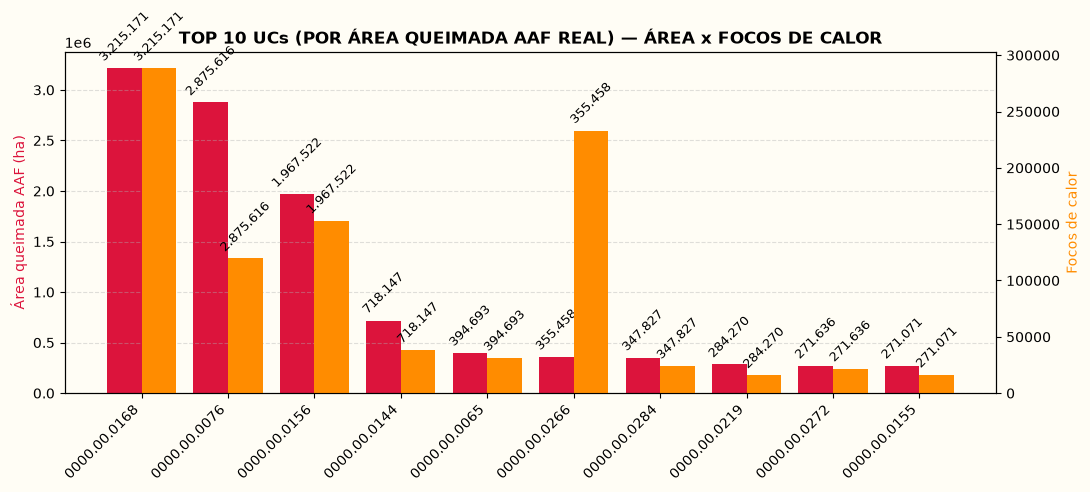

In [95]:
# Top 10 UCs — área queimada real x total de focos de calor

aaf_area_by_uc = gdf_aaf_metric.groupby('cnuc')['area_ha_cell'].sum().rename('aaf_area_ha')
hotspot_count_by_uc = (
    gdf_inpe_with_cell.merge(cell_uc_membership, on='cell_id', how='left')
    .groupby('cnuc').size().rename('hotspot_count')
)

top10_area = (
    pd.concat([aaf_area_by_uc, hotspot_count_by_uc], axis=1)
    .fillna(0)
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'aaf_area_ha')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_area))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_area['aaf_area_ha'], width, color='crimson', label='Área queimada AAF (ha)')
ax1.bar_label(bars1, labels= format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax1.set_ylabel('Área queimada AAF (ha)', color='crimson')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_area['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_area['hotspot_count'], width, color='darkorange', label='Focos de calor')
ax2.bar_label(bars2, labels=format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax2.set_ylabel('Focos de calor', color='darkorange')

plt.title('TOP 10 UCs (POR ÁREA QUEIMADA AAF REAL) — ÁREA x FOCOS DE CALOR', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top10_ucs_area_x_focos.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

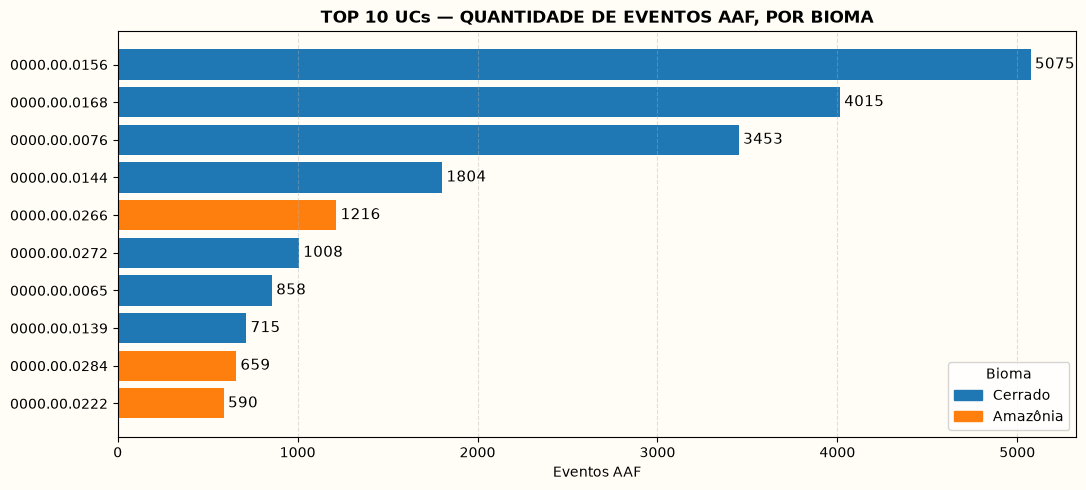

In [96]:
# Top 10 UCs — quantidade de eventos por bioma predominante

uc_info = gdf_ucs_metric[['cnuc', 'nomeuc', 'bioma_pred']].drop_duplicates()

top10_events_bioma = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(uc_info, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

biomas_unicos = top10_events_bioma['bioma_pred'].unique()
cores_bioma = dict(zip(biomas_unicos, plt.cm.tab10.colors[:len(biomas_unicos)]))
cores_barras = top10_events_bioma['bioma_pred'].map(cores_bioma)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.barh(top10_events_bioma['cnuc'], top10_events_bioma['n_events'], color=cores_barras)
ax.bar_label(bars, fmt='%.0f', fontsize=11, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Eventos AAF')
ax.set_title('TOP 10 UCs — QUANTIDADE DE EVENTOS AAF, POR BIOMA', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=cor) for cor in cores_bioma.values()]
ax.legend(legend_handles, cores_bioma.keys(), title='Bioma', loc='lower right')

plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_biomas.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

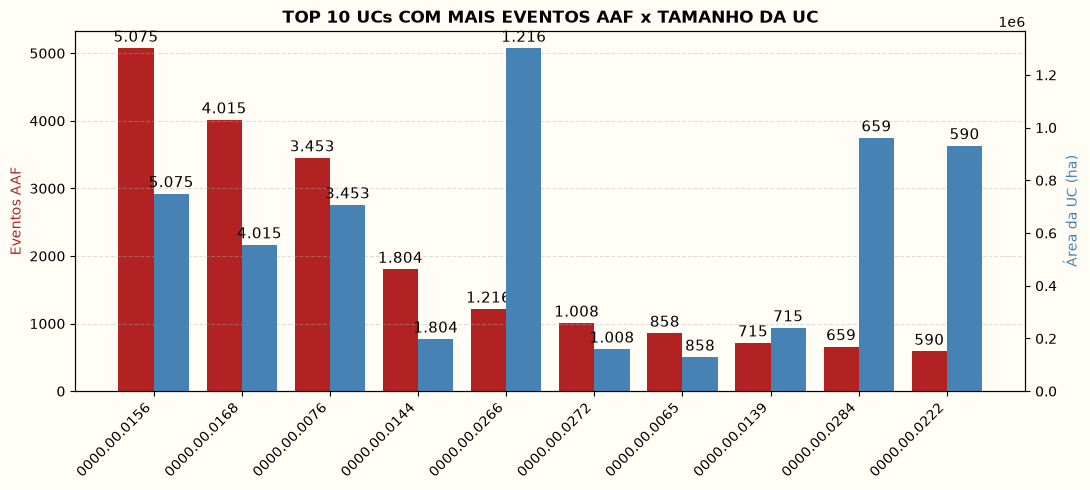

In [97]:
# Top 10 UCs por eventos, comparadas ao tamanho (área total) da UC

top10_events_size = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_events_size))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_events_size['n_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_events_size['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_events_size['areahaalb'], width, color='steelblue', label='Área da UC (ha)')
ax2.bar_label(bars2, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax2.set_ylabel('Área da UC (ha)', color='steelblue')

plt.title('TOP 10 UCs COM MAIS EVENTOS AAF x TAMANHO DA UC', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_vs_ha_uc.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Temporal — anual, mensal, acumulado

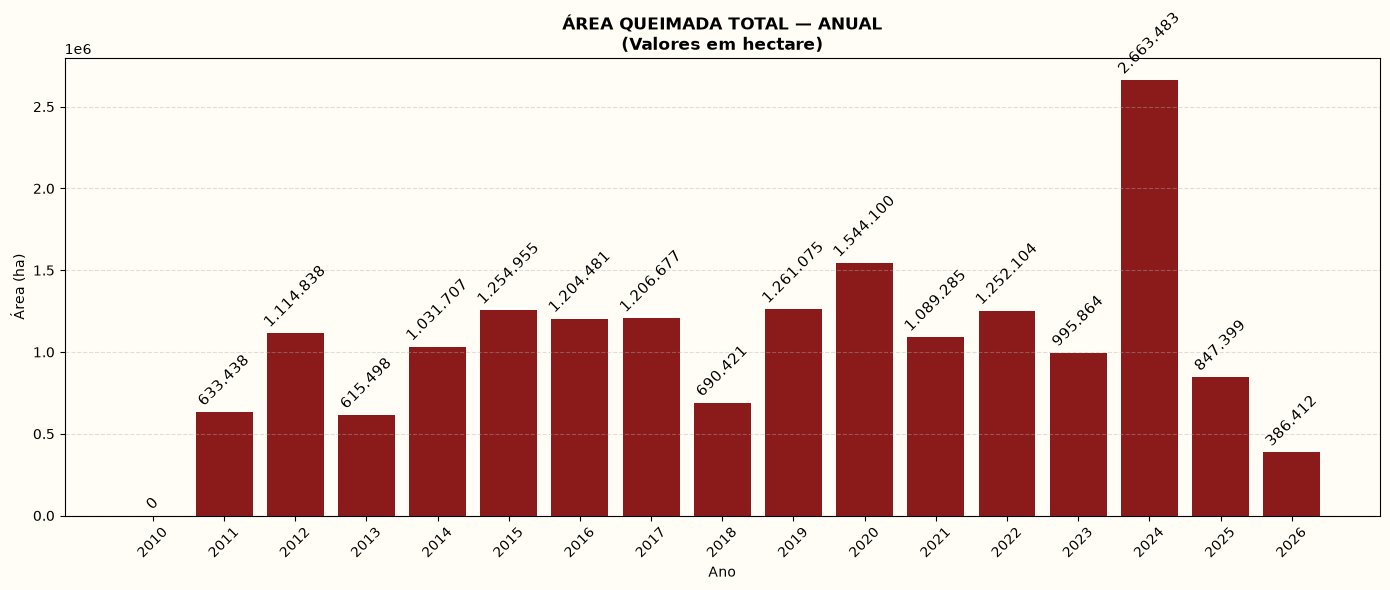

In [98]:
# Área queimada total, por ano

annual_area = gdf_aaf_metric.groupby('event_year')['area_ha_cell'].sum().reindex(range(2010, 2027), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(annual_area.index.astype(str), annual_area.values, color='#8b1a1a')
ax.bar_label(bars, labels=format_thousands(annual_area.values), fontsize=11, rotation=45, padding=2)

ax.set_xlabel('Ano')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — ANUAL\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_total_anual.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

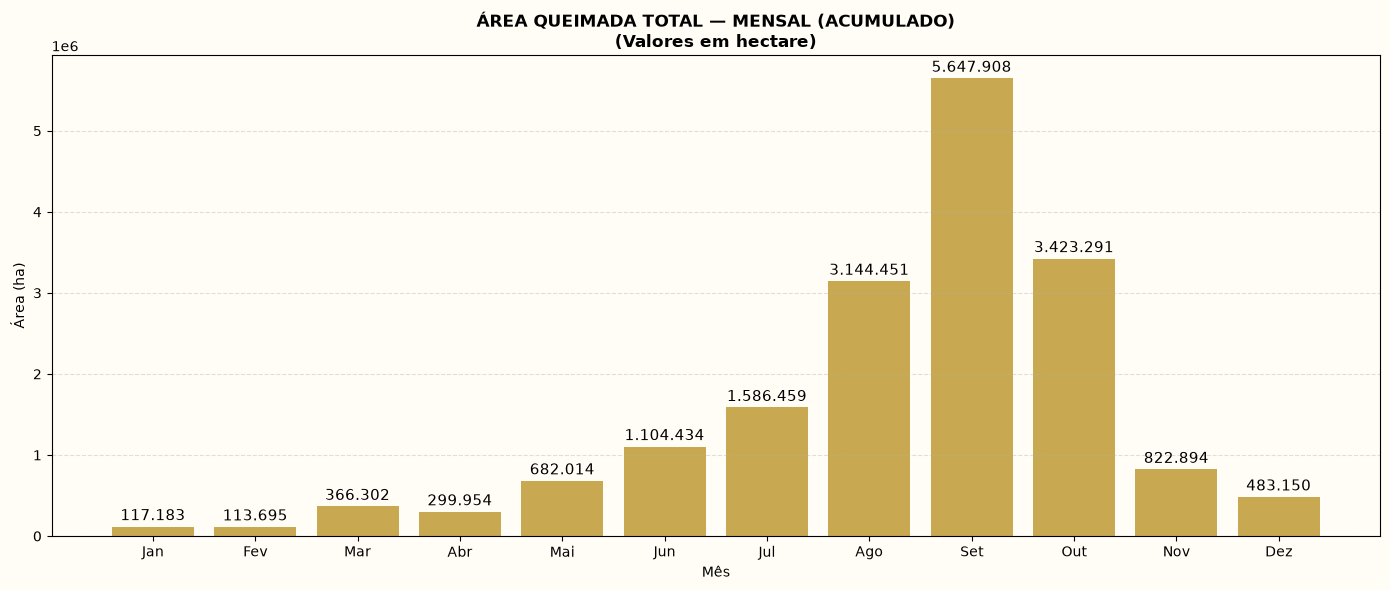

In [99]:
# Área queimada total, por mês (acumulado, todos os anos)

monthly_area = gdf_aaf_metric.groupby('event_month')['area_ha_cell'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(months_label, monthly_area.values, color='#c8a951')
ax.bar_label(bars, labels=format_thousands(monthly_area.values), fontsize=11, padding=2)

ax.set_xlabel('Mês')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — MENSAL (ACUMULADO)\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_total_mensal.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

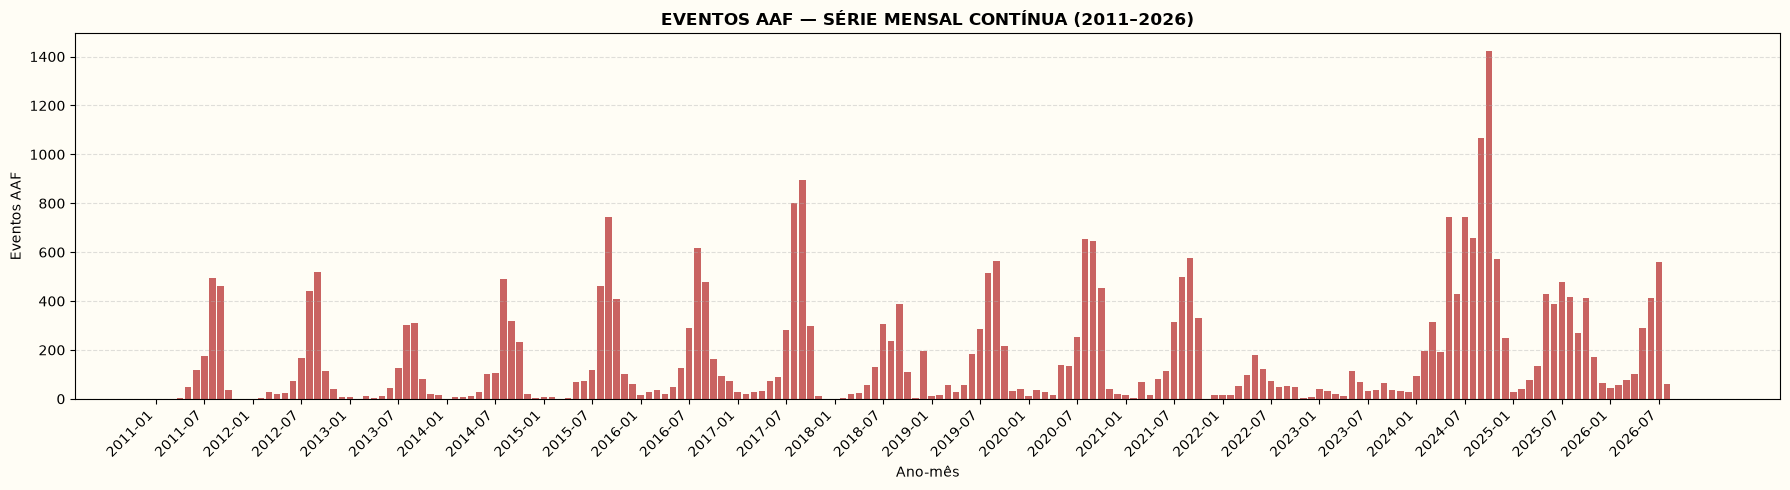

In [100]:
# Série mensal contínua, sem acumular anos (cada ponto = um mês de um ano específico)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_events_unique['year_month'] = pd.to_datetime(
    aaf_events_unique['event_year'].astype(int).astype(str) + '-' +
    aaf_events_unique['event_month'].astype(int).astype(str)
).dt.to_period('M')

events_by_yearmonth = aaf_events_unique.groupby('year_month').size()

full_range = pd.period_range(start=f'{min_year}-01', end=f'{max_year}-12', freq='M')
events_by_yearmonth = events_by_yearmonth.reindex(full_range, fill_value=0)

x_labels = full_range.astype(str)

fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.bar(x_labels, events_by_yearmonth.values, color='firebrick', alpha=0.7)
ax.set_xticks(range(0, len(x_labels), 6))
ax.set_xticklabels(x_labels[::6], rotation=45, ha='right')
ax.set_xlabel('Ano-mês')
ax.set_ylabel('Eventos AAF')
ax.set_title(f'EVENTOS AAF — SÉRIE MENSAL CONTÍNUA ({min_year}–{max_year})', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_2011_2026.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Comparativo AAF x INPE (bioma, temporal)


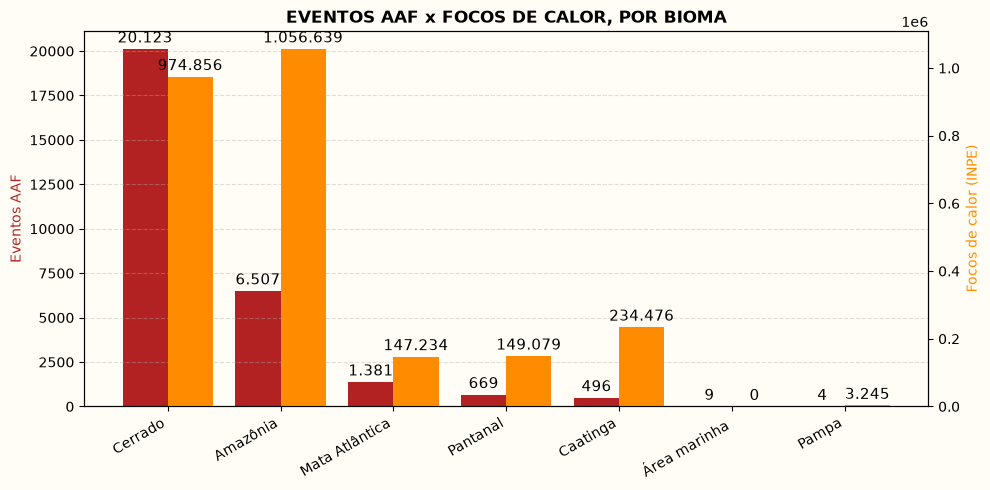

In [102]:
# Eventos AAF x focos INPE, por bioma

uc_bioma = gdf_ucs_metric[['cnuc', 'bioma_pred']].drop_duplicates()

aaf_by_bioma = (
    aaf_events_unique.merge(uc_bioma, on='cnuc', how='left')
    .groupby('bioma_pred').size().rename('aaf_events')
)
inpe_by_bioma = gdf_inpe_with_cell.groupby('bioma', observed=True).size().rename('inpe_hotspots')

biome_comparison = pd.concat([aaf_by_bioma, inpe_by_bioma], axis=1).fillna(0)
biome_comparison = biome_comparison.sort_values('aaf_events', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

x = np.arange(len(biome_comparison))
width = 0.4

bars1 = ax1.bar(x - width/2, biome_comparison['aaf_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(biome_comparison['aaf_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(biome_comparison.index, rotation=30, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, biome_comparison['inpe_hotspots'], width, color='darkorange', label='Focos INPE')
ax2.bar_label(bars2, labels=format_thousands(biome_comparison['inpe_hotspots']), fontsize=11, padding=2)
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title('EVENTOS AAF x FOCOS DE CALOR, POR BIOMA', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_vs_inpe_biomas.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

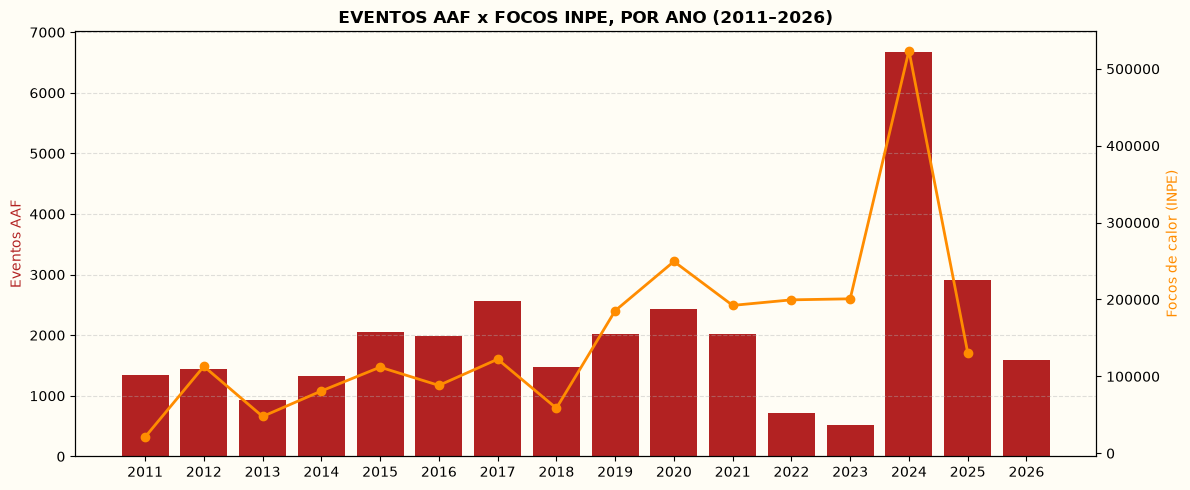

In [103]:
# Eventos AAF x focos INPE, por ano (mesmo intervalo do AAF)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_by_year = aaf_events_unique.groupby('event_year').size()
inpe_by_year = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('file_year').size()

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(aaf_by_year.index.astype(str), aaf_by_year.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(aaf_by_year.index.astype(str), inpe_by_year.reindex(aaf_by_year.index).values,
          color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR ANO ({min_year}–{max_year})', fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_vs_inpe_ano.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


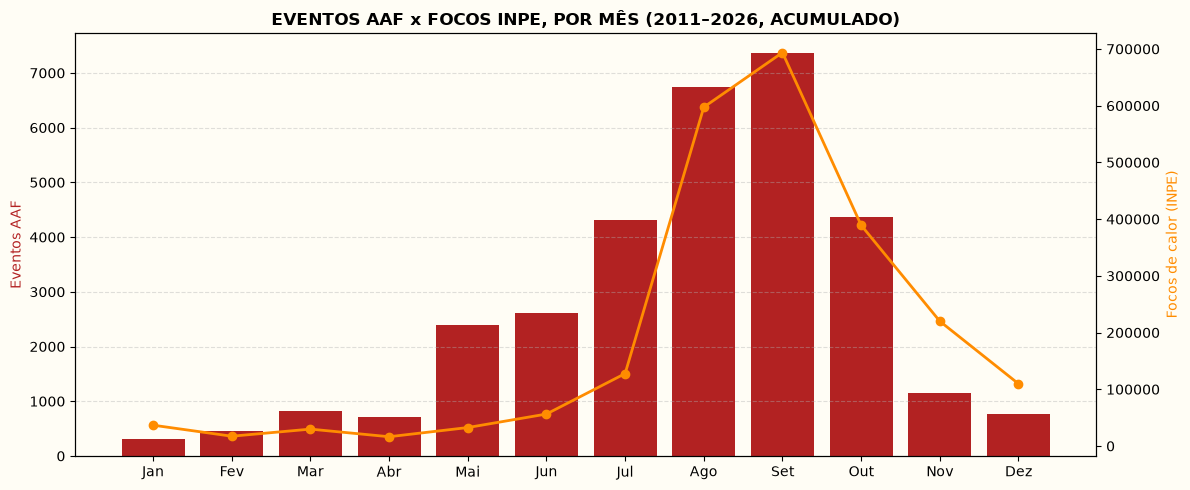

In [104]:
# Eventos AAF x focos INPE, por mês (acumulado, mesmo intervalo do AAF)

aaf_by_month = aaf_events_unique.groupby('event_month').size().reindex(range(1, 13), fill_value=0)

gdf_inpe_with_cell['month'] = pd.to_datetime(gdf_inpe_with_cell['data_pas'], errors='coerce').dt.month
inpe_by_month = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('month').size().reindex(range(1, 13), fill_value=0)

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(months_label, aaf_by_month.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(months_label, inpe_by_month.values, color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR MÊS ({min_year}–{max_year}, ACUMULADO)', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aff_vs_inpe_mes.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

### Tipo de evento harmonizado (contagem, área, FRP, espacial)


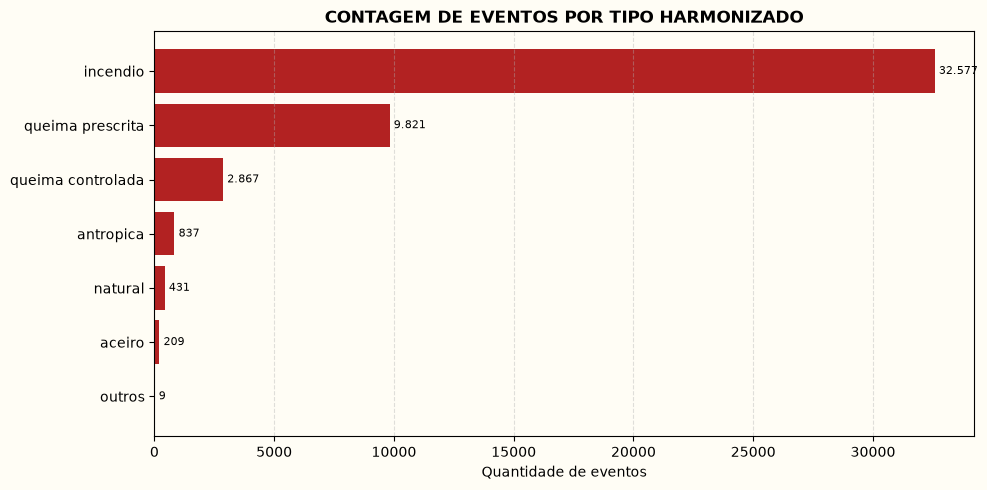

In [105]:
# Contagem de eventos por tipo

event_type_counts = gdf_aaf_metric.dropna(subset=['event_type'])['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars = ax.barh(event_type_counts.index, event_type_counts.values, color='firebrick')
ax.bar_label(bars, labels=format_thousands(event_type_counts.values), fontsize=8, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Quantidade de eventos')
ax.set_title('CONTAGEM DE EVENTOS POR TIPO HARMONIZADO', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "aaf_por_tipo.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [107]:
# FRP médio associado a cada tipo harmonizado (vínculo aproximado: mesma célula + ano + mês)

frp_by_cell_period = (
    gdf_inpe_with_cell.groupby(['cell_id', 'file_year', 'month'])['frp']
    .mean()
    .rename('frp_mean_period')
    .reset_index()
)

aaf_with_frp = gdf_aaf_metric.dropna(subset=['event_type']).merge(
    frp_by_cell_period,
    left_on=['cell_id', 'file_year', 'event_month'],
    right_on=['cell_id', 'file_year', 'month'],
    how='inner'
)

aaf_with_frp['event_type'].value_counts()

event_type
incendio             25664
queima prescrita      5301
queima controlada     1948
antropica              619
natural                359
aceiro                  88
outros                   8
Name: count, dtype: int64

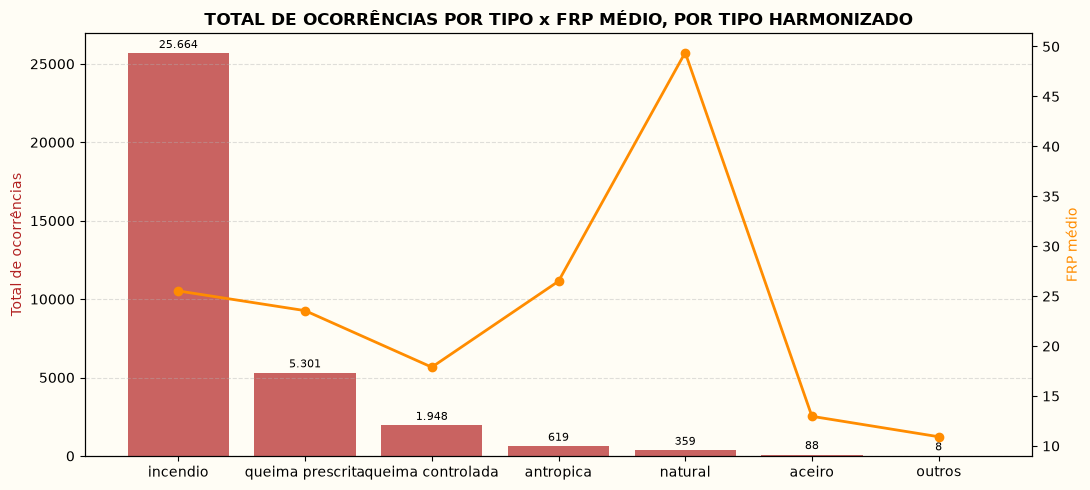

In [108]:
# Total de ocorrências por tipo x FRP médio, por tipo harmonizado

occurrence_by_type = aaf_with_frp['event_type'].value_counts()
frp_mean_by_type = aaf_with_frp.groupby('event_type')['frp_mean_period'].mean()

combo_df = pd.concat([occurrence_by_type.rename('n_events'), frp_mean_by_type.rename('frp_mean')], axis=1)
combo_df = combo_df.sort_values('n_events', ascending=False)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

bars = ax1.bar(combo_df.index, combo_df['n_events'], color='firebrick', alpha=0.7, label='Ocorrências')
ax1.bar_label(bars, labels=format_thousands(combo_df['n_events']), fontsize=8, padding=2)
ax1.set_ylabel('Total de ocorrências', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(combo_df.index, combo_df['frp_mean'], color='darkorange', marker='o', linewidth=2, label='FRP médio')
ax2.set_ylabel('FRP médio', color='darkorange')

plt.title('TOTAL DE OCORRÊNCIAS POR TIPO x FRP MÉDIO, POR TIPO HARMONIZADO', fontweight='bold')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "tipo_vs_frp_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


### Regime do Fogo

In [109]:
#  FRP médio e máximo, por célula — todas as células com foco de calor dentro das UCs

frp_by_cell_full = gdf_inpe_with_cell.groupby('cell_id')['frp'].agg(
    frp_mean='mean', frp_max='max', n_hotspots='count'
).dropna(subset=['frp_mean'])

total_cells = len(gdf_grid)
cells_with_hotspot = gdf_inpe_with_cell['cell_id'].nunique()
cells_with_frp = len(frp_by_cell_full)
cells_no_hotspot = total_cells - cells_with_hotspot

print(f"Total de células na grade: {total_cells}")
print(f"Células com pelo menos 1 foco de calor: {cells_with_hotspot}")
print(f"Células com FRP calculável (foco válido, não nulo): {cells_with_frp}")
print(f"Células sem nenhum foco de calor registrado: {cells_no_hotspot}")

Total de células na grade: 82045
Células com pelo menos 1 foco de calor: 22550
Células com FRP calculável (foco válido, não nulo): 16489
Células sem nenhum foco de calor registrado: 59495


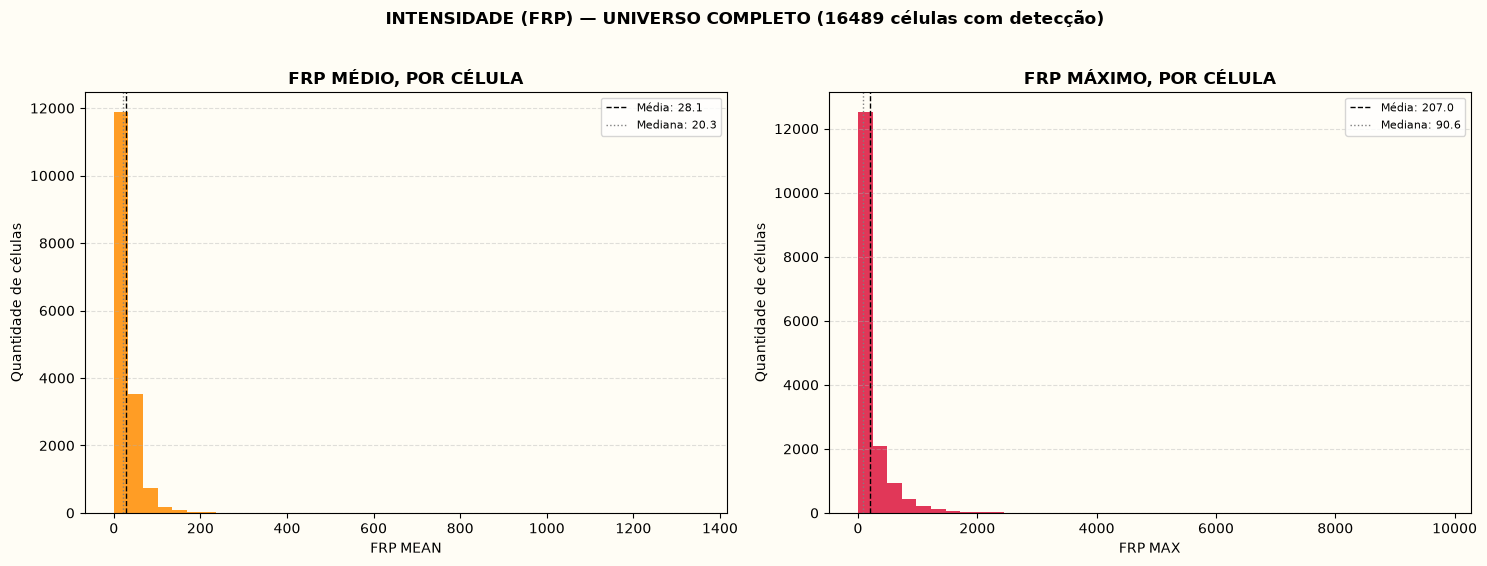

In [110]:
# Histogramas — FRP médio e máximo, com estatísticas-chave marcadas

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor("#FFFDF5")

for ax, col, color, title in [
    (axes[0], 'frp_mean', 'darkorange', 'FRP MÉDIO, POR CÉLULA'),
    (axes[1], 'frp_max', 'crimson', 'FRP MÁXIMO, POR CÉLULA'),
]:
    ax.set_facecolor("#FFFDF5")
    data = frp_by_cell_full[col]
    ax.hist(data, bins=40, color=color, alpha=0.85)

    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Média: {mean_val:,.1f}'.replace(',', '.'))
    ax.axvline(median_val, color='gray', linestyle=':', linewidth=1, label=f'Mediana: {median_val:,.1f}'.replace(',', '.'))

    ax.set_xlabel(col.replace('_', ' ').upper())
    ax.set_ylabel('Quantidade de células')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'INTENSIDADE (FRP) — UNIVERSO COMPLETO ({cells_with_frp} células com detecção)', fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "frp.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

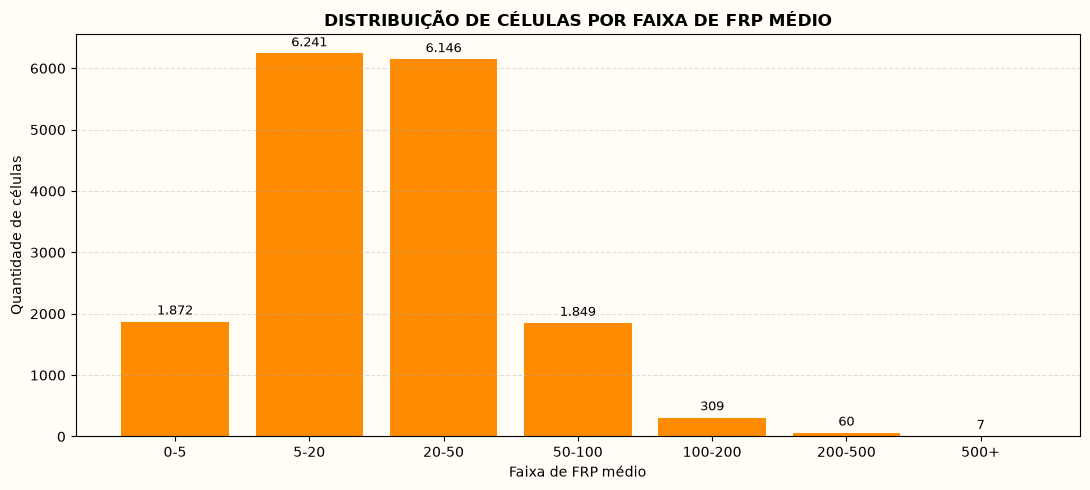

In [112]:
# Comparativo — % de células por faixa de FRP médio (visão de distribuição em degraus)

frp_bins = [0, 5, 20, 50, 100, 200, 500, float('inf')]
frp_labels = ['0-5', '5-20', '20-50', '50-100', '100-200', '200-500', '500+']

frp_by_cell_full['frp_range'] = pd.cut(frp_by_cell_full['frp_mean'], bins=frp_bins, labels=frp_labels)
frp_range_counts = frp_by_cell_full['frp_range'].value_counts().reindex(frp_labels)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars = ax.bar(frp_range_counts.index.astype(str), frp_range_counts.values, color='darkorange')
ax.bar_label(bars, labels=format_thousands(frp_range_counts.values), fontsize=9, padding=3)
ax.set_xlabel('Faixa de FRP médio')
ax.set_ylabel('Quantidade de células')
ax.set_title('DISTRIBUIÇÃO DE CÉLULAS POR FAIXA DE FRP MÉDIO', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "distribuicao_cel_frp_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

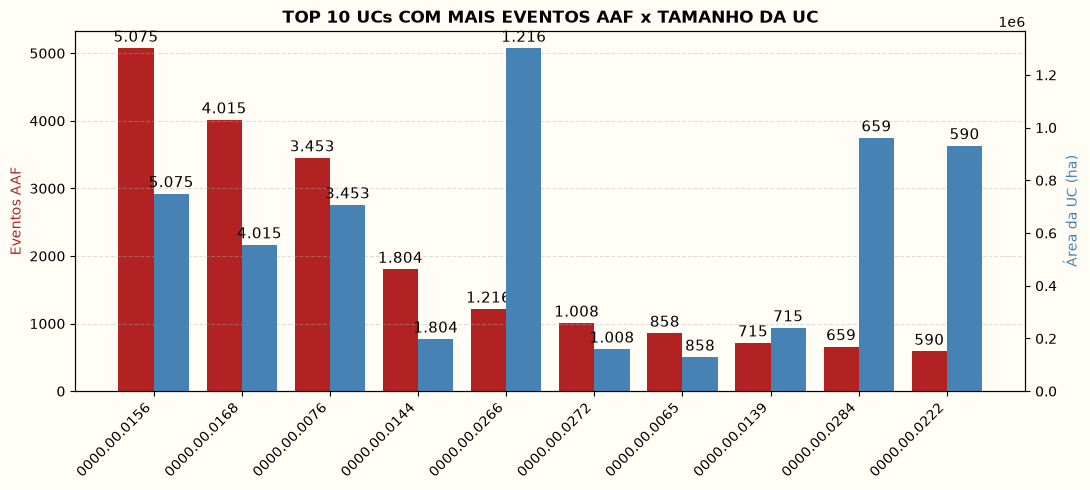

In [ ]:
# Top 10 UCs por eventos, comparadas ao tamanho (área total) da UC

top10_events_size = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_events_size))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_events_size['n_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_events_size['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_events_size['areahaalb'], width, color='steelblue', label='Área da UC (ha)')
ax2.bar_label(bars2, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax2.set_ylabel('Área da UC (ha)', color='steelblue')

plt.title('TOP 10 UCs COM MAIS EVENTOS AAF x TAMANHO DA UC', fontweight='bold')
fig.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "top_10_uc_qtd_aaf_vs_ha_uc.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [58]:
# Anos distintos com evento e FRI médio, por célula

years_by_cell = gdf_aaf_metric.groupby('cell_id')['event_year'].apply(lambda x: sorted(x.unique()))

def mean_return_interval(years_list):
    if len(years_list) < 2:
        return np.nan
    return np.diff(years_list).mean()

fri_by_cell = pd.DataFrame({
    'cell_id': years_by_cell.index,
    'n_fire_years': years_by_cell.apply(len),
    'fri_mean': years_by_cell.apply(mean_return_interval),
}).reset_index(drop=True)

total_cells = len(gdf_grid)
cells_with_aaf = len(fri_by_cell)
cells_never_burned = total_cells - cells_with_aaf
cells_single_year = (fri_by_cell['n_fire_years'] == 1).sum()
cells_fri_calculable = fri_by_cell['fri_mean'].notna().sum()

print(f"Total de células na grade: {total_cells}")
print(f"Células sem nenhum evento AAF: {cells_never_burned}")
print(f"Células com evento AAF em apenas 1 ano (FRI não calculável): {cells_single_year}")
print(f"Células com FRI calculável (2+ anos distintos): {cells_fri_calculable}")
print()
print("FRI médio — estatísticas (apenas células calculáveis):")
print(fri_by_cell['fri_mean'].describe())

Total de células na grade: 82045
Células sem nenhum evento AAF: 75379
Células com evento AAF em apenas 1 ano (FRI não calculável): 2446
Células com FRI calculável (2+ anos distintos): 4220

FRI médio — estatísticas (apenas células calculáveis):
count    4220.000000
mean        2.839449
std         2.248782
min         1.000000
25%         1.250000
50%         2.000000
75%         3.500000
max        14.000000
Name: fri_mean, dtype: float64


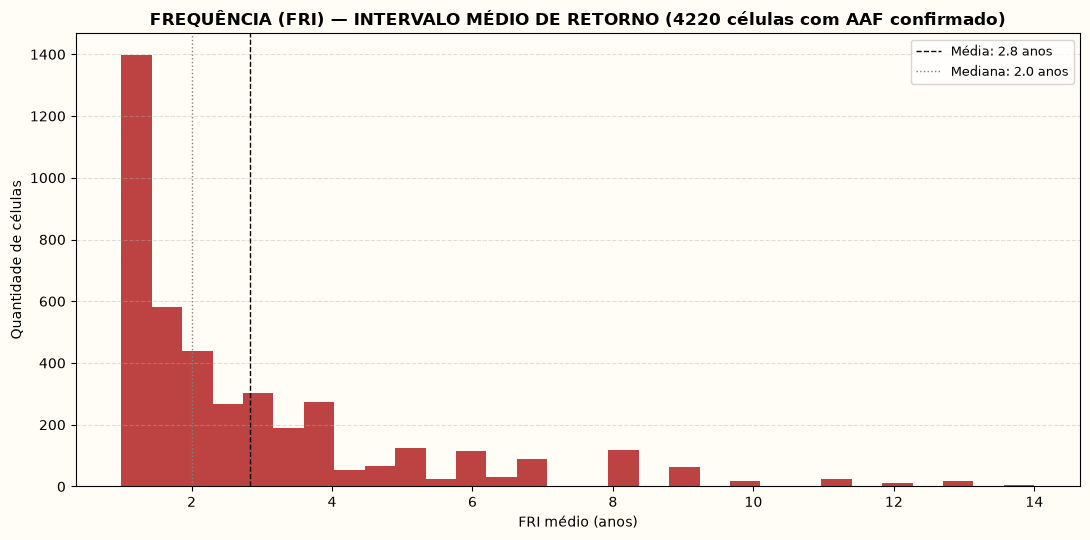

In [118]:
# Histograma do FRI médio, com estatísticas-chave marcadas

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

fri_valid = fri_by_cell['fri_mean'].dropna()
ax.hist(fri_valid, bins=30, color='firebrick', alpha=0.85)

mean_val = fri_valid.mean()
median_val = fri_valid.median()
ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Média: {mean_val:.1f} anos')
ax.axvline(median_val, color='gray', linestyle=':', linewidth=1, label=f'Mediana: {median_val:.1f} anos')

ax.set_xlabel('FRI médio (anos)')
ax.set_ylabel('Quantidade de células')
ax.set_title(f'FREQUÊNCIA (FRI) — INTERVALO MÉDIO DE RETORNO ({cells_fri_calculable} células com AAF confirmado)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "fri_intervalo_medio.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


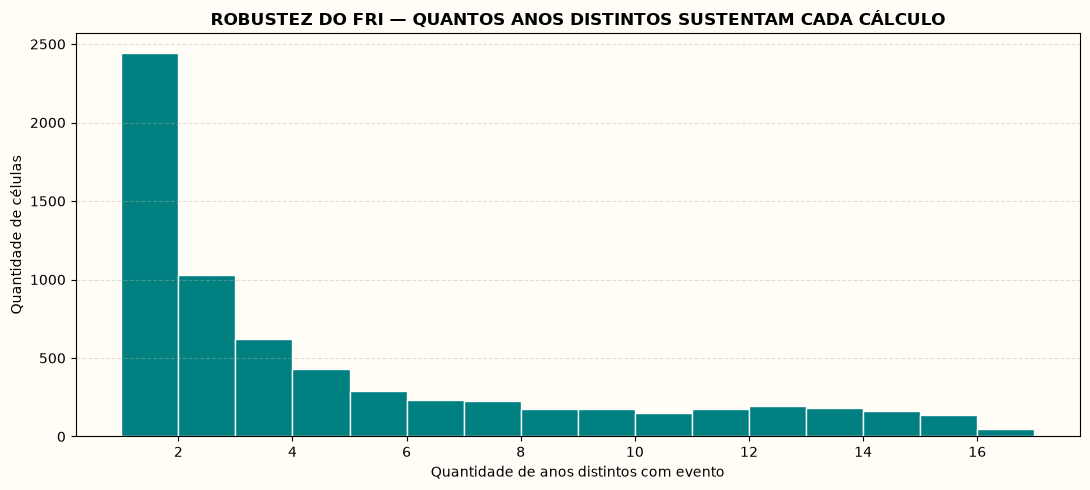

In [119]:
# Distribuição de quantas vezes (anos distintos) cada célula queimou — robustez do FRI

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

ax.hist(fri_by_cell['n_fire_years'], bins=range(1, 18), color='teal', edgecolor='white')
ax.set_xlabel('Quantidade de anos distintos com evento')
ax.set_ylabel('Quantidade de células')
ax.set_title('ROBUSTEZ DO FRI — QUANTOS ANOS DISTINTOS SUSTENTAM CADA CÁLCULO', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "fri_ano.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()


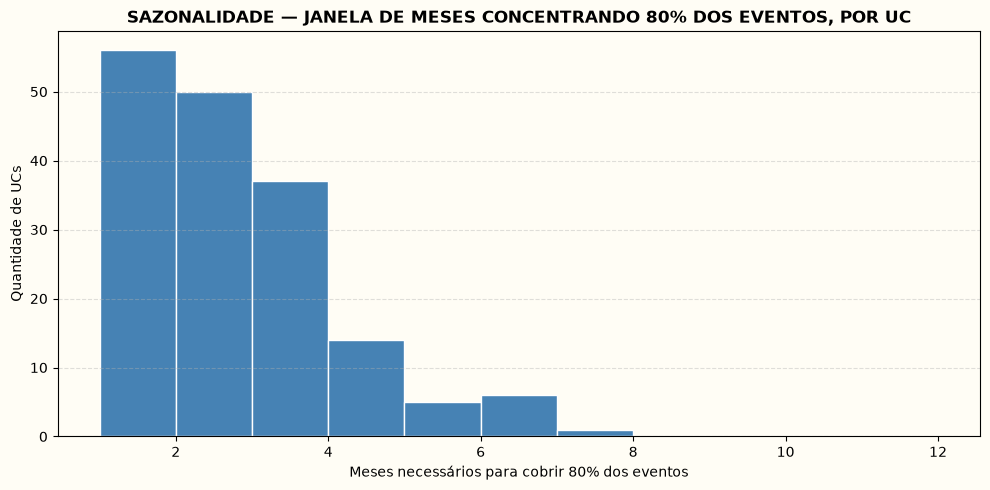

In [120]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos, por UC

def seasonal_window(months, coverage=0.8):
    # ordena meses pela frequência, acumula até atingir a cobertura desejada, retorna quantos meses foram necessários
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

seasonal_by_uc = (
    gdf_aaf_metric.dropna(subset=['cnuc'])
    .groupby('cnuc')['event_month']
    .apply(lambda x: seasonal_window(x, 0.8))
    .rename('n_months_80pct')
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(seasonal_by_uc, bins=range(1, 13), color='steelblue', edgecolor='white')
ax.set_xlabel('Meses necessários para cobrir 80% dos eventos')
ax.set_ylabel('Quantidade de UCs')
ax.set_title('SAZONALIDADE — JANELA DE MESES CONCENTRANDO 80% DOS EVENTOS, POR UC', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "sazonalidade.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

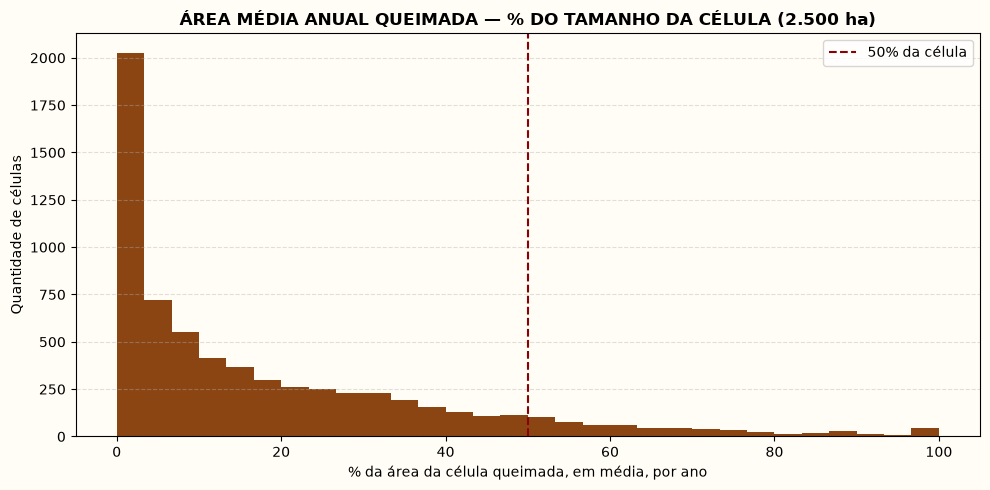

In [124]:
# Área média anual queimada — por célula, comparada ao tamanho da célula (2.500 ha)

CELL_AREA_HA = 2500  # 5km x 5km

annual_area_by_cell = gdf_aaf_metric.groupby(['cell_id', 'event_year'])['area_ha_cell'].sum().reset_index()
mean_annual_area_by_cell = annual_area_by_cell.groupby('cell_id')['area_ha_cell'].mean()
pct_of_cell_burned = (mean_annual_area_by_cell / CELL_AREA_HA * 100).clip(upper=100)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(pct_of_cell_burned, bins=30, color='saddlebrown')
ax.axvline(50, color='darkred', linestyle='--', label='50% da célula')
ax.set_xlabel('% da área da célula queimada, em média, por ano')
ax.set_ylabel('Quantidade de células')
ax.set_title('ÁREA MÉDIA ANUAL QUEIMADA — % DO TAMANHO DA CÉLULA (2.500 ha)', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "area_media_anual_queimada.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [64]:
# Mapa interativo (geemap) — top 10 UCs, reaproveitando top10_area e seasonal_by_uc já calculados

top10_ucs_geom = gdf_ucs_metric[gdf_ucs_metric['cnuc'].isin(top10_area['cnuc'])].to_crs(4326)

n_events_by_uc = aaf_events_unique.groupby('cnuc').size().rename('n_events')
max_event_by_uc = aaf_events_unique.groupby('cnuc')['area_ha'].max().rename('max_event_ha')
n_years_by_uc = aaf_events_unique.groupby('cnuc')['event_year'].nunique().rename('n_years_with_fire')

def mean_return_interval(years_list):
    if len(years_list) < 2:
        return np.nan
    return np.diff(sorted(years_list)).mean()

fri_by_uc = (
    aaf_events_unique.groupby('cnuc')['event_year']
    .apply(lambda x: mean_return_interval(x.unique()))
    .rename('fri_mean')
)

annual_area_by_uc_year = gdf_aaf_metric.groupby(['cnuc', 'event_year'])['area_ha_cell'].sum().reset_index()
annual_area_mean_by_uc = annual_area_by_uc_year.groupby('cnuc')['area_ha_cell'].mean().rename('annual_area_mean')

frp_by_uc = (
    gdf_inpe_with_cell.merge(cell_uc_membership, on='cell_id', how='left')
    .groupby('cnuc')['frp']
    .mean()
    .rename('frp_mean')
)

top10_ucs_geom = (
    top10_ucs_geom
    .merge(top10_area[['cnuc', 'aaf_area_ha', 'hotspot_count']], on='cnuc', how='left')
    .merge(n_events_by_uc, on='cnuc', how='left')
    .merge(max_event_by_uc, on='cnuc', how='left')
    .merge(n_years_by_uc, on='cnuc', how='left')
    .merge(fri_by_uc, on='cnuc', how='left')
    .merge(seasonal_by_uc, on='cnuc', how='left')
    .merge(annual_area_mean_by_uc, on='cnuc', how='left')
    .merge(frp_by_uc, on='cnuc', how='left')
)

tooltip_gdf = top10_ucs_geom[[
    'nomeuc', 'bioma_pred', 'areahaalb', 'aaf_area_ha',
    'hotspot_count', 'n_events', 'max_event_ha', 'n_years_with_fire',
    'fri_mean', 'frp_mean', 'n_months_80pct', 'annual_area_mean',
    'geometry'
]].rename(columns={
    'nomeuc': 'Nome',
    'bioma_pred': 'Bioma',
    'areahaalb': 'Área total UC (ha)',
    'aaf_area_ha': 'Área queimada acumulada AAF (ha)',
    'hotspot_count': 'Focos de calor',
    'n_events': 'Eventos únicos AAF',
    'max_event_ha': 'Maior evento único registrado (ha)',
    'n_years_with_fire': 'Anos distintos com fogo',
    'fri_mean': 'FRI médio (anos)',
    'frp_mean': 'FRP médio',
    'n_months_80pct': 'Sazonalidade (meses p/ 80% dos eventos)',
    'annual_area_mean': 'Área média anual queimada (ha)',
})

for col in ['Área total UC (ha)', 'Área queimada acumulada AAF (ha)', 'Maior evento único registrado (ha)', 'Área média anual queimada (ha)']:
    tooltip_gdf[col] = tooltip_gdf[col].round(0)

for col in ['FRI médio (anos)', 'FRP médio']:
    tooltip_gdf[col] = tooltip_gdf[col].round(2)

Map = geemap.Map()

Map.add_gdf(
    tooltip_gdf,
    layer_name="Top 10 UCs (AAF)",
    style={"color": "crimson", "fillColor": "crimson", "fillOpacity": 0.3, "weight": 2},
    info_mode="on_hover",
)

Map.centerObject(geemap.gdf_to_ee(tooltip_gdf), zoom=5)
Map.add_basemap('HYBRID')
Map

Map(center=[-9.858185784342313, -52.22973230286052], controls=(WidgetControl(options=['position', 'transparent…

In [65]:
# Limpeza de memória

del (
    aaf_area_by_uc,
    hotspot_count_by_uc,
    top10_area,
    uc_info,
    top10_events_bioma,
    biomas_unicos,
    cores_bioma,
    cores_barras,
    top10_events_size,
    annual_area,
    monthly_area,
    min_year,
    max_year,
    events_by_yearmonth,
    full_range,
    x_labels,
    uc_bioma,
    aaf_by_bioma,
    inpe_by_bioma,
    biome_comparison,
    aaf_by_year,
    inpe_by_year,
    aaf_by_month,
    inpe_by_month,
    event_type_counts,
    frp_by_cell_period,
    aaf_with_frp,
    occurrence_by_type,
    frp_mean_by_type,
    combo_df,
    frp_by_cell_full,
    total_cells,
    cells_with_hotspot,
    cells_with_frp,
    cells_no_hotspot,
    frp_bins,
    frp_labels,
    frp_range_counts,
    years_by_cell,
    fri_by_cell,
    cells_with_aaf,
    cells_never_burned,
    cells_single_year,
    cells_fri_calculable,
    fri_valid,
    seasonal_by_uc,
    CELL_AREA_HA,
    annual_area_by_cell,
    mean_annual_area_by_cell,
    pct_of_cell_burned,
)
gc.collect()

3316

# Pré-processamento

Essa é a etapa que transforma a EDA em algo que um algoritmo consegue processar: as cinco variáveis do regime de fogo calculadas por célula, com um critério explícito de quando confiar em cada valor e quando não confiar.

- **Thresholds de robustez.** Cada variável exige um mínimo de observações pra ser considerada confiável. FRI e área média anual pedem pelo menos 3 anos distintos com evento. Sazonalidade pede pelo menos 3 eventos. FRP pede pelo menos 5 focos de calor detectados. Tamanho máximo não tem threshold, porque mesmo um único evento já é um valor físico real, não uma estimativa estatística que precisa de repetição.

- **Cálculo das cinco variáveis, célula por célula.** FRI, sazonalidade, tamanho e área média vêm do AAF. FRP vem do foco de calor. Cada uma sai como uma tabela independente, com o valor calculado e uma marcação de confiabilidade.

- **União num vetor único.** As cinco tabelas são unidas numa só, cobrindo as 82.045 células da grade inteira, não só as que tinham dado. Isso deixa claro, de cara, que a cobertura de dado confiável é pequena: das 82 mil células, pouco mais de 6.600 têm algum evento de AAF registrado.

- **Tratamento da ausência.** Pra FRP, tamanho e área média, ausência de evento vira zero, porque zero tem significado físico real ali (nunca houve fogo ou energia detectada). Pra FRI e sazonalidade não existe um número honesto pra "nunca aconteceu", então essas duas viram uma categoria separada, distinguindo célula sem nenhum registro de célula com registro insuficiente.

- **Segmentação em dois grupos.** Só as células confiáveis nas cinco variáveis ao mesmo tempo entram na classificação por clusterização, o Grupo A. Todo o resto recebe um rótulo fixo de regime de fogo raro ou dado insuficiente, o Grupo B. No fim, o Grupo A ficou em torno de 3,8% do total.

- **Normalização.** As variáveis com cauda longa, FRP, tamanho e área média, passam por log antes da padronização, pra suavizar os valores extremos. FRI e sazonalidade são padronizadas direto.

- **Clusterização.** K-means testado de 3 a 8 grupos, escolhido pelo silhouette score. K igual a 3 teve o melhor resultado entre os testados.

- **Interpretação e persistência.** Os três clusters são descritos pelas variáveis originais, não normalizadas, pra facilitar entender o que cada grupo representa. O vetor final, com geometria e bioma reanexados, é salvo em Parquet.


**Descobertas e observações:**

- **Cobertura de dado confiável é baixa.** Só 3,8% da grade tem as cinco variáveis calculáveis ao mesmo tempo, reflexo direto de 16 anos de série sendo pouco tempo pra malha tão fina de 5 por 5 km.

- **Os três clusters têm perfis distintos.** Um grupo concentra fogo mais frequente mas de menor intensidade e extensão, outro concentra fogo muito frequente e extenso, e o terceiro concentra fogo raro mas intenso, com estação mais curta.

In [149]:
(
    gdf_grid,
    cell_uc_membership,
    gdf_aaf_metric,
    aaf_events_unique,
    gdf_inpe_with_cell,
    gdf_ucs_metric,
) = load_prepared_data(FILES_DIR)

Grid: (1871136, 2)
Cell-UC membership: (1891159, 2)
AAF (recortado por célula): (429470, 41)
AAF (eventos únicos): (32026, 41)
INPE: (2565532, 13)
UCs: (347, 22)


In [ ]:
ucs_com_aaf = gdf_aaf_metric['cnuc'].dropna().unique()
print("UCs com pelo menos 1 evento AAF:", len(ucs_com_aaf))

UCs com pelo menos 1 evento AAF: 169


In [ ]:
gdf_ucs_ativas = gdf_ucs_metric[gdf_ucs_metric['cnuc'].isin(ucs_com_aaf)].copy()
print("UCs restantes no universo restrito:", len(gdf_ucs_ativas))



UCs restantes no universo restrito: 168


In [155]:
global_minx, global_miny, _, _ = gdf_ucs_ativas.total_bounds

grid_records = []

for idx, row in gdf_ucs_ativas.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({"cell_id": f"{i}_{j}", "geometry": clipped})

gdf_grid_restrito = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
gdf_grid_restrito = gdf_grid_restrito.dissolve(by="cell_id", as_index=False)

print("Total de células no universo restrito:", len(gdf_grid_restrito))

Total de células no universo restrito: 587107


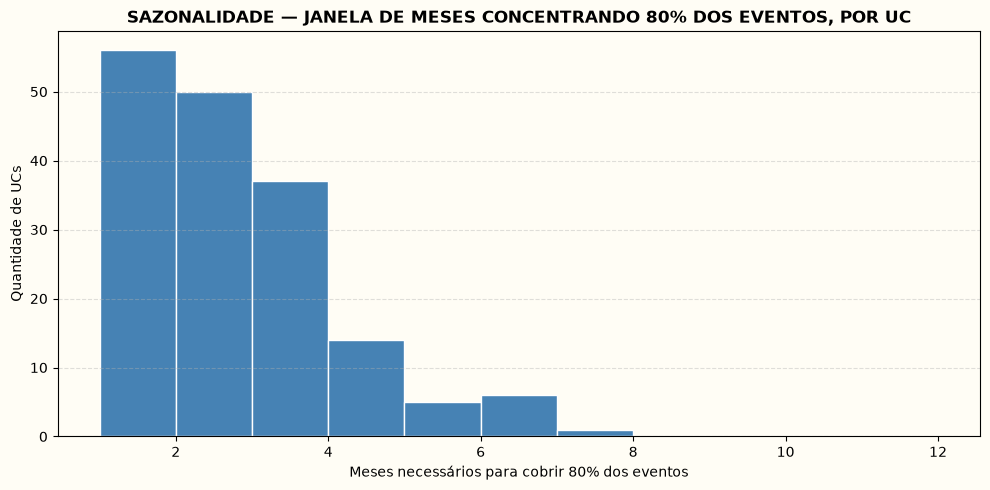

In [ ]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos, por UC

def seasonal_window(months, coverage=0.8):
    # ordena meses pela frequência, acumula até atingir a cobertura desejada, retorna quantos meses foram necessários
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

seasonal_by_uc = (
    gdf_aaf_metric.dropna(subset=['cnuc'])
    .groupby('cnuc')['event_month']
    .apply(lambda x: seasonal_window(x, 0.8))
    .rename('n_months_80pct')
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(seasonal_by_uc, bins=range(1, 13), color='steelblue', edgecolor='white')
ax.set_xlabel('Meses necessários para cobrir 80% dos eventos')
ax.set_ylabel('Quantidade de UCs')
ax.set_title('SAZONALIDADE — JANELA DE MESES CONCENTRANDO 80% DOS EVENTOS, POR UC', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "sazonalidade.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [67]:
# Universo final: todas as células da grade
TOTAL_CELLS = len(gdf_grid)
print("Total de células:", TOTAL_CELLS)

Total de células: 82045


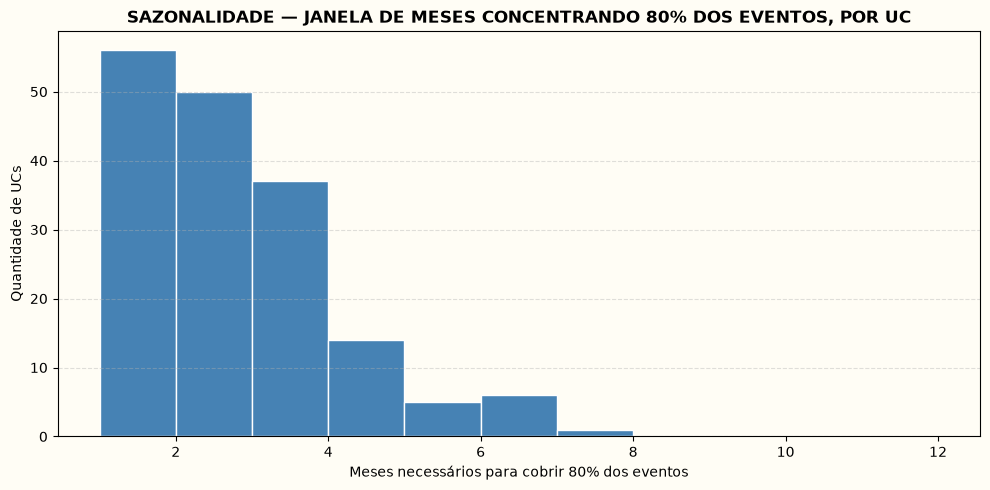

In [ ]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos, por UC

def seasonal_window(months, coverage=0.8):
    # ordena meses pela frequência, acumula até atingir a cobertura desejada, retorna quantos meses foram necessários
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

seasonal_by_uc = (
    gdf_aaf_metric.dropna(subset=['cnuc'])
    .groupby('cnuc')['event_month']
    .apply(lambda x: seasonal_window(x, 0.8))
    .rename('n_months_80pct')
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(seasonal_by_uc, bins=range(1, 13), color='steelblue', edgecolor='white')
ax.set_xlabel('Meses necessários para cobrir 80% dos eventos')
ax.set_ylabel('Quantidade de UCs')
ax.set_title('SAZONALIDADE — JANELA DE MESES CONCENTRANDO 80% DOS EVENTOS, POR UC', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(PRINTS_DIR, "sazonalidade.png"), dpi=200, bbox_inches='tight', facecolor='#FFFDF5')
plt.show()

In [68]:
# Thresholds de robustez: mínimo de observações para considerar cada variável confiável

MIN_YEARS_FOR_FRI = 3  # anos distintos com evento
MIN_HOTSPOTS_FOR_FRP = 5  # focos de calor detectados
MIN_EVENTS_FOR_SEASONALITY = 3
MIN_YEARS_FOR_AREA = 3

In [69]:
# FRI — intervalo médio de retorno (AAF)

def mean_return_interval(years_list):
    # média dos intervalos entre anos consecutivos com evento; exige 2+ anos
    if len(years_list) < 2:
        return np.nan
    return np.diff(years_list).mean()


years_by_cell = gdf_aaf_metric.groupby("cell_id")["event_year"].apply(
    lambda x: sorted(x.unique())
)

fri_raw = pd.DataFrame(
    {
        "cell_id": years_by_cell.index,
        "n_fire_years": years_by_cell.apply(len),
        "fri_mean": years_by_cell.apply(mean_return_interval),
    }
).reset_index(drop=True)

fri_raw["fri_reliable"] = fri_raw["n_fire_years"] >= MIN_YEARS_FOR_FRI

print("Células com evento AAF:", len(fri_raw))
print(
    f"Células com FRI confiável (>={MIN_YEARS_FOR_FRI} anos):",
    fri_raw["fri_reliable"].sum(),
)

Células com evento AAF: 6666
Células com FRI confiável (>=3 anos): 3191


In [70]:
# FRP — intensidade média e máxima (INPE)
frp_raw = (
    gdf_inpe_with_cell.groupby("cell_id")["frp"]
    .agg(frp_mean="mean", frp_max="max", n_hotspots="count")
    .reset_index()
    .dropna(subset=["frp_mean"])
)

frp_raw["frp_reliable"] = frp_raw["n_hotspots"] >= MIN_HOTSPOTS_FOR_FRP

print("Células com FRP calculável:", len(frp_raw))
print(
    f"Células com FRP confiável (>={MIN_HOTSPOTS_FOR_FRP} hotspots):",
    frp_raw["frp_reliable"].sum(),
)

Células com FRP calculável: 16489
Células com FRP confiável (>=5 hotspots): 11889


In [71]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos (AAF)
def seasonal_window(months, coverage=0.8):
    # quantos meses (do mais ativo ao menos ativo) somam a cobertura desejada
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

seasonality_raw = (
    gdf_aaf_metric.groupby('cell_id')['event_month']
    .agg(n_months_80pct=lambda x: seasonal_window(x, 0.8), n_events='size')
    .reset_index()
)

seasonality_raw['seasonality_reliable'] = seasonality_raw['n_events'] >= MIN_EVENTS_FOR_SEASONALITY

print("Células com sazonalidade calculável:", len(seasonality_raw))
print(f"Células com sazonalidade confiável (>={MIN_EVENTS_FOR_SEASONALITY} eventos):", seasonality_raw['seasonality_reliable'].sum())

Células com sazonalidade calculável: 6666
Células com sazonalidade confiável (>=3 eventos): 4256


In [72]:
# Tamanho — maior evento por célula (AAF)

size_raw = (
    gdf_aaf_metric.groupby('cell_id')['area_ha_cell']
    .agg(size_max='max', n_events='size')
    .reset_index()
)

print("Células com evento AAF:", len(size_raw))

Células com evento AAF: 6666


In [73]:
# Área média anual queimada (AAF)

annual_area_by_year = gdf_aaf_metric.groupby(['cell_id', 'event_year'])['area_ha_cell'].sum().reset_index()

annual_area_raw = (
    annual_area_by_year.groupby('cell_id')['area_ha_cell']
    .agg(annual_area_mean='mean', n_years='size')
    .reset_index()
)

annual_area_raw['area_reliable'] = annual_area_raw['n_years'] >= MIN_YEARS_FOR_AREA

print("Células com área anual calculável:", len(annual_area_raw))
print(f"Células com área anual confiável (>={MIN_YEARS_FOR_AREA} anos):", annual_area_raw['area_reliable'].sum())

Células com área anual calculável: 6666
Células com área anual confiável (>=3 anos): 3191


In [74]:
# União das 5 variáveis num único vetor por célula, cobrindo o universo completo (82.045)

fire_regime_vector = gdf_grid[['cell_id']].copy()

fire_regime_vector = fire_regime_vector.merge(
    fri_raw[['cell_id', 'fri_mean', 'n_fire_years', 'fri_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    frp_raw[['cell_id', 'frp_mean', 'frp_max', 'n_hotspots', 'frp_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    seasonality_raw[['cell_id', 'n_months_80pct', 'seasonality_reliable']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    size_raw[['cell_id', 'size_max']], on='cell_id', how='left'
)
fire_regime_vector = fire_regime_vector.merge(
    annual_area_raw[['cell_id', 'annual_area_mean', 'area_reliable']], on='cell_id', how='left'
)

print("Total de células no vetor final:", len(fire_regime_vector))


Total de células no vetor final: 82045


In [75]:
# Codificar ausência de dado por variável:
# - FRP, tamanho, área média: zero tem significado físico real (nunca houve fogo/energia detectada)
# - FRI e sazonalidade: não existe número honesto para "nunca aconteceu" — viram categoria à parte

fire_regime_vector['frp_mean'] = fire_regime_vector['frp_mean'].fillna(0)
fire_regime_vector['frp_max'] = fire_regime_vector['frp_max'].fillna(0)
fire_regime_vector['size_max'] = fire_regime_vector['size_max'].fillna(0)
fire_regime_vector['annual_area_mean'] = fire_regime_vector['annual_area_mean'].fillna(0)

# Categoria de status para FRI — separa "sem registro nenhum" de "registro insuficiente" de "confiável"
def fri_status(row):
    if pd.isna(row['n_fire_years']):
        return 'sem_registro'
    elif not row['fri_reliable']:
        return 'insuficiente'
    else:
        return 'confiavel'

fire_regime_vector['fri_status'] = fire_regime_vector.apply(fri_status, axis=1)

# Mesma lógica para sazonalidade
def seasonality_status(row):
    if pd.isna(row['n_months_80pct']):
        return 'sem_registro'
    elif not row['seasonality_reliable']:
        return 'insuficiente'
    else:
        return 'confiavel'

fire_regime_vector['seasonality_status'] = fire_regime_vector.apply(seasonality_status, axis=1)

# Preencher os flags booleanos restantes (frp_reliable) onde ficaram NaN
fire_regime_vector['frp_reliable'] = fire_regime_vector['frp_reliable'].fillna(False)
fire_regime_vector['area_reliable'] = fire_regime_vector['area_reliable'].fillna(False)

print(fire_regime_vector[['fri_status', 'seasonality_status']].apply(lambda col: col.value_counts()))
fire_regime_vector.head(10)

              fri_status  seasonality_status
confiavel           3191                4256
insuficiente        3475                2410
sem_registro       75379               75379


,cell_id,fri_mean,n_fire_years,fri_reliable,frp_mean,frp_max,n_hotspots,frp_reliable,n_months_80pct,seasonality_reliable,size_max,annual_area_mean,area_reliable,fri_status,seasonality_status
0,0_575,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
1,0_576,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
2,0_579,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
3,0_580,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
4,1000_189,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
5,1000_190,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
6,1000_191,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
7,1000_192,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
8,1000_193,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro
9,1000_194,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro


In [76]:
# Segmentação em dois grupos:
# Grupo A — confiável nas 5 variáveis simultaneamente, entra no clustering real
# Grupo B — o resto, recebe classificação fixa de "regime raro/sem dado suficiente"

fire_regime_vector['group'] = np.where(
    (fire_regime_vector['fri_status'] == 'confiavel') &
    (fire_regime_vector['frp_reliable'] == True) &
    (fire_regime_vector['seasonality_status'] == 'confiavel') &
    (fire_regime_vector['area_reliable'] == True),
    'A_confiavel',
    'B_insuficiente'
)

print(fire_regime_vector['group'].value_counts())
print(f"\nPercentual no Grupo A: {(fire_regime_vector['group'] == 'A_confiavel').mean() * 100:.1f}%")

group
B_insuficiente    78907
A_confiavel        3138
Name: count, dtype: int64

Percentual no Grupo A: 3.8%


In [77]:
fire_regime_vector['group'].describe()

count              82045
unique                 2
top       B_insuficiente
freq               78907
Name: group, dtype: object

In [78]:
# Isolar o Grupo A para normalização e clustering

group_a = fire_regime_vector[fire_regime_vector['group'] == 'A_confiavel'].copy()

print("Células no Grupo A:", len(group_a))
print(group_a[['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']].describe())

Células no Grupo A: 3138
          fri_mean     frp_mean  n_months_80pct     size_max  annual_area_mean
count  3138.000000  3138.000000     3138.000000  3138.000000       3138.000000
mean      2.147649    38.187996        3.094009   973.851391        601.349235
std       1.268486    24.966661        1.115467   730.767809        474.112202
min       1.000000     2.240741        1.000000     5.953380          3.384906
25%       1.200000    21.609262        2.000000   348.465590        215.980272
50%       1.666667    33.362038        3.000000   793.807726        493.424978
75%       2.666667    48.750138        4.000000  1523.527112        871.075226
max       7.500000   336.644989        7.000000  2500.000000       2632.357710


In [79]:
# Normalização — log1p nas variáveis com cauda longa, depois z-score em todas

from scipy import stats

# Colunas com forte assimetria (desvio padrão > média, cauda longa) recebem log1p antes do z-score
log_transform_cols = ['frp_mean', 'size_max', 'annual_area_mean']
direct_zscore_cols = ['fri_mean', 'n_months_80pct']

group_a_norm = group_a[['cell_id']].copy()

for col in log_transform_cols:
    logged = np.log1p(group_a[col])
    group_a_norm[f'{col}_norm'] = (logged - logged.mean()) / logged.std()

for col in direct_zscore_cols:
    group_a_norm[f'{col}_norm'] = (group_a[col] - group_a[col].mean()) / group_a[col].std()

print(group_a_norm.describe())
group_a_norm.head(10)

       frp_mean_norm  size_max_norm  annual_area_mean_norm  fri_mean_norm  n_months_80pct_norm
count   3.138000e+03   3.138000e+03           3.138000e+03   3.138000e+03         3.138000e+03
mean   -7.293876e-09   1.449163e-16          -5.977797e-16  -4.528634e-17        -5.434361e-17
std     1.000000e+00   1.000000e+00           1.000000e+00   1.000000e+00         1.000000e+00
min    -3.947199e+00  -4.211102e+00          -4.224885e+00  -9.047397e-01        -1.877248e+00
25%    -6.481067e-01  -5.671224e-01          -5.654783e-01  -7.470714e-01        -9.807628e-01
50%     6.279901e-02   1.972649e-01           2.069784e-01  -3.791787e-01        -8.427761e-02
75%     6.912822e-01   8.031775e-01           7.392268e-01   4.091629e-01         8.122076e-01
max     3.943541e+00   1.263661e+00           1.775754e+00   4.219480e+00         3.501663e+00


,cell_id,frp_mean_norm,size_max_norm,annual_area_mean_norm,fri_mean_norm,n_months_80pct_norm
12289,108_511,-0.330820,-3.896303,-3.789097,1.460285,-0.084278
12329,109_511,-0.271972,-2.060630,-1.663218,1.460285,-0.084278
12529,114_508,-0.630813,-4.211102,-4.224885,1.460285,-0.980763
12530,114_509,-0.551441,-3.061558,-3.102672,1.460285,-0.980763
12600,117_507,-0.503995,-0.577252,-0.721326,1.460285,-0.980763
12625,118_507,-0.863485,-1.637301,-1.603275,1.460285,-0.084278
12626,118_508,-0.874509,-4.153980,-4.141694,1.066114,-0.084278
12725,120_510,-0.066540,-3.222541,-3.324812,1.066114,-0.084278
13108,130_517,-0.833987,-3.250764,-3.417488,1.066114,-0.084278
13231,133_516,0.467123,-3.474040,-3.511901,1.066114,-0.084278


In [80]:
# K-means — testar K de 3 a 8, usando inércia (cotovelo) e silhouette score

feature_cols = ['frp_mean_norm', 'size_max_norm', 'annual_area_mean_norm', 'fri_mean_norm', 'n_months_80pct_norm']
X = group_a_norm[feature_cols].values

results = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)

    results.append({'k': k, 'inertia': inertia, 'silhouette': silhouette})
    print(f"K={k} | Inércia={inertia:.1f} | Silhouette={silhouette:.3f}")

results_df = pd.DataFrame(results)

K=3 | Inércia=8772.4 | Silhouette=0.284
K=4 | Inércia=7412.3 | Silhouette=0.239
K=5 | Inércia=6547.9 | Silhouette=0.224
K=6 | Inércia=5938.6 | Silhouette=0.226
K=7 | Inércia=5535.8 | Silhouette=0.224
K=8 | Inércia=5159.6 | Silhouette=0.218


In [81]:
# K-means final com K=3, interpretação dos clusters

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
group_a_norm['cluster'] = kmeans_final.fit_predict(group_a_norm[feature_cols].values)

print("Distribuição de células por cluster:")
print(group_a_norm['cluster'].value_counts().sort_index())

Distribuição de células por cluster:
cluster
0     619
1    1668
2     851
Name: count, dtype: int64


In [82]:
# Trazer as variáveis originais (não normalizadas) para interpretar o significado de cada cluster

group_a_interpret = group_a.merge(
    group_a_norm[['cell_id', 'cluster']], on='cell_id', how='left'
)

cluster_summary = group_a_interpret.groupby('cluster')[
    ['fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean']
].agg(['mean', 'median', 'count'])

print(cluster_summary)

         fri_mean                   frp_mean                  n_months_80pct                  size_max                    annual_area_mean                  
             mean    median count       mean     median count           mean median count         mean       median count             mean      median count
cluster                                                                                                                                                     
0        3.877252  3.666667   619  46.441799  41.665871   619       2.281099    2.0   619  1074.237597   882.356827   619       729.981836  615.999325   619
1        1.438316  1.300000  1668  41.434525  37.598969  1668       3.651679    4.0  1668  1322.813408  1234.803191  1668       790.929924  724.596201  1668
2        2.279898  2.000000   851  25.820997  21.260000   851       2.592244    3.0   851   216.850562   189.596792   851       136.197447  116.909994   851


In [83]:
# Atribuir cluster real ao Grupo A, e rótulo fixo ao Grupo B

fire_regime_vector['fire_regime_cluster'] = 'B_dado_insuficiente'

cluster_map = dict(zip(group_a_norm['cell_id'], group_a_norm['cluster']))

mask_group_a = fire_regime_vector['cell_id'].isin(cluster_map)
fire_regime_vector.loc[mask_group_a, 'fire_regime_cluster'] = (
    fire_regime_vector.loc[mask_group_a, 'cell_id'].map(cluster_map).astype(str)
)

print(fire_regime_vector['fire_regime_cluster'].value_counts())

fire_regime_cluster
B_dado_insuficiente    78907
1                       1668
2                        851
0                        619
Name: count, dtype: int64


In [84]:
print("Group A original:", len(group_a_norm))
print("Células mapeadas para cluster:", mask_group_a.sum())

Group A original: 3138
Células mapeadas para cluster: 3138


In [85]:
# Reanexar geometria (para visualização espacial futura) e bioma (via UC associada)

fire_regime_final = fire_regime_vector.merge(
    gdf_grid[['cell_id', 'geometry']], on='cell_id', how='left'
)

# Bioma predominante da UC associada a cada célula
cell_biome = cell_uc_membership.merge(
    gdf_ucs_metric[['cnuc', 'bioma_pred']].drop_duplicates(), on='cnuc', how='left'
)[['cell_id', 'bioma_pred']].drop_duplicates(subset='cell_id')

fire_regime_final = fire_regime_final.merge(cell_biome, on='cell_id', how='left')

fire_regime_final = gpd.GeoDataFrame(fire_regime_final, geometry='geometry', crs=gdf_grid.crs)

print("Total de células no vetor final:", len(fire_regime_final))
print("\nColunas:", fire_regime_final.columns.tolist())
fire_regime_final.head(5)

Total de células no vetor final: 82045

Colunas: ['cell_id', 'fri_mean', 'n_fire_years', 'fri_reliable', 'frp_mean', 'frp_max', 'n_hotspots', 'frp_reliable', 'n_months_80pct', 'seasonality_reliable', 'size_max', 'annual_area_mean', 'area_reliable', 'fri_status', 'seasonality_status', 'group', 'fire_regime_cluster', 'geometry', 'bioma_pred']


,cell_id,fri_mean,n_fire_years,fri_reliable,frp_mean,frp_max,n_hotspots,frp_reliable,n_months_80pct,seasonality_reliable,size_max,annual_area_mean,area_reliable,fri_status,seasonality_status,group,fire_regime_cluster,geometry,bioma_pred
0,0_575,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro,B_insuficiente,B_dado_insuficiente,"POLYGON ((2799437.509 9109977.642, 2799353.31 ...",Amazônia
1,0_576,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro,B_insuficiente,B_dado_insuficiente,"POLYGON ((2794566.026 9116409.696, 2794745.492...",Amazônia
2,0_579,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro,B_insuficiente,B_dado_insuficiente,"POLYGON ((2799272.736 9131051.609, 2799190.336...",Amazônia
3,0_580,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro,B_insuficiente,B_dado_insuficiente,"POLYGON ((2797141.395 9134793.207, 2797027.858...",Amazônia
4,1000_189,NaN,NaN,NaN,0.0,0.0,NaN,False,NaN,NaN,0.0,0.0,False,sem_registro,sem_registro,B_insuficiente,B_dado_insuficiente,"POLYGON ((7795442.382 7184234.726, 7794457.32 ...",Área marinha


In [86]:
# Persistir o vetor final do regime de fogo

OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")

fire_regime_final.to_parquet(os.path.join(OUTPUTS_DIR, "fire_regime_vector.parquet"))

print("Salvo em:", os.path.join(OUTPUTS_DIR, "fire_regime_vector.parquet"))
print(f"Tamanho: {os.path.getsize(os.path.join(OUTPUTS_DIR, 'fire_regime_vector.parquet')) / 1e6:.1f} MB")

Salvo em: files\prepared\fire_regime_vector.parquet
Tamanho: 25.5 MB


In [87]:
# Cruzamento cluster x bioma 

group_a_biome = fire_regime_final[
    fire_regime_final['fire_regime_cluster'].isin(['0', '1', '2'])
]

cluster_biome_crosstab = pd.crosstab(
    group_a_biome['fire_regime_cluster'],
    group_a_biome['bioma_pred'],
    margins=True
)

cluster_biome_crosstab

bioma_pred,Amazônia,Caatinga,Cerrado,Mata Atlântica,Pantanal,Área marinha,All
fire_regime_cluster,,,,,,,
0,248,47,260,44,20,0,619
1,270,13,1302,40,43,0,1668
2,379,25,321,123,1,2,851
All,897,85,1883,207,64,2,3138


In [88]:
# Mesmo cruzamento, em percentual por cluster (linha soma 100%)

cluster_biome_pct = pd.crosstab(
    group_a_biome['fire_regime_cluster'],
    group_a_biome['bioma_pred'],
    normalize='index'
) * 100

cluster_biome_pct.round(1)

bioma_pred,Amazônia,Caatinga,Cerrado,Mata Atlântica,Pantanal,Área marinha
fire_regime_cluster,,,,,,
0,40.1,7.6,42.0,7.1,3.2,0.0
1,16.2,0.8,78.1,2.4,2.6,0.0
2,44.5,2.9,37.7,14.5,0.1,0.2


In [89]:
# Mapa interativo (geemap) — clusters de regime de fogo + contorno das UCs, centralizado no Brasil

group_a_map = fire_regime_final[
    fire_regime_final['fire_regime_cluster'].isin(['0', '1', '2'])
].to_crs(4326)

cluster_colors = {'0': '#f4a582', '1': '#b2182b', '2': '#2166ac'}

Map = geemap.Map(center=[-14.2350, -51.9253], zoom=4)

# Contorno das UCs, sem preenchimento
Map.add_gdf(
    gdf_ucs_metric.to_crs(4326),
    layer_name="Limites das UCs",
    style={"color": "black", "fillOpacity": 0, "weight": 1},
    info_mode=None,
)

for cluster_value, color in cluster_colors.items():
    subset = group_a_map[group_a_map['fire_regime_cluster'] == cluster_value]

    tooltip_gdf = subset[[
        'fri_mean', 'frp_mean', 'n_months_80pct', 'size_max', 'annual_area_mean', 'bioma_pred', 'geometry'
    ]].rename(columns={
        'fri_mean': 'FRI médio (anos)',
        'frp_mean': 'FRP médio',
        'n_months_80pct': 'Sazonalidade (meses p/ 80%)',
        'size_max': 'Maior evento (ha)',
        'annual_area_mean': 'Área média anual (ha)',
        'bioma_pred': 'Bioma',
    })

    for col in ['FRI médio (anos)', 'FRP médio', 'Maior evento (ha)', 'Área média anual (ha)']:
        tooltip_gdf[col] = tooltip_gdf[col].round(2)

    Map.add_gdf(
        tooltip_gdf,
        layer_name=f"Cluster {cluster_value}",
        style={"color": color, "fillColor": color, "fillOpacity": 0.6, "weight": 0},
        info_mode="on_hover",
    )

Map.add_basemap('HYBRID')
Map

Map(center=[-14.235, -51.9253], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

# Modelagem / treinamento


# Avaliação do modelo


# Ajuste de hiperparâmetros


# Validação final
